# Hypothesis Testing
___

## Normal Distribution Theory
___

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom, norm

In [2]:
# --- Configurações globais ---
rng = np.random.default_rng(seed=42)

To start, let's think of a question:

Let's say there is a fair coin (P = 0.5), and we flip it 20 times (N = 20).

What is the number of heads (k) that maximizes the probability in the binomial distribution?

In [3]:
n, p = 20, 0.5
probs = [(k, binom.pmf(k, n, p)) for k in range(n+1)]
max_k, max_prob = max(probs, key=lambda x: x[1])

print(f"k = {max_k}, P(X=k) = {max_prob:.4f}")

k = 10, P(X=k) = 0.1762


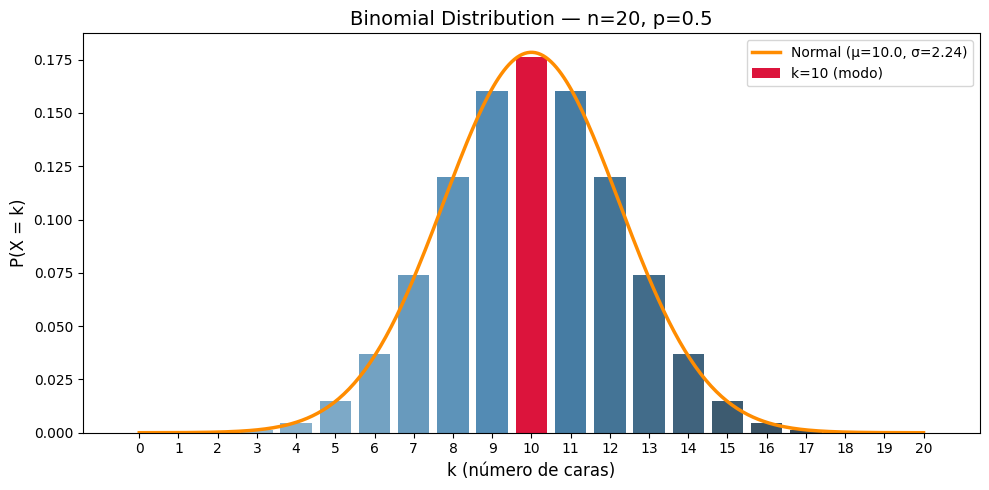

In [4]:
n, p = 20, 0.5
k_values = list(range(n + 1))
probs = [binom.pmf(k, n, p) for k in k_values]

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(x=k_values, y=probs, hue=k_values, palette="Blues_d", legend=False, ax=ax)
ax.bar(10, binom.pmf(10, n, p), color="crimson", label="k=10 (modo)")

# curva normal (aproximação pelo CLT)
mu = n * p          # 10
sigma = np.sqrt(n * p * (1 - p))  # ~2.24
x = np.linspace(0, 20, 300)
ax.plot(x, norm.pdf(x, mu, sigma), color="darkorange", linewidth=2.5, label=f"Normal (μ={mu}, σ={sigma:.2f})")

ax.set_title("Binomial Distribution — n=20, p=0.5", fontsize=14)
ax.set_xlabel("k (número de caras)", fontsize=12)
ax.set_ylabel("P(X = k)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Normal Distribution

The bell curve is often called a **normal distribution**.  
A normal distribution has two parameters: mean $\mu$ and variance $\sigma^2$.

### Quadratic Difference

For any outcome $x$, the quadratic difference between the value $x$ and $\mu$ can be written as:

$$
(x - \mu)^2
$$

## Normal Distribution

The **normal distribution** can be written as:

$$
N(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} * e^{-\frac{1}{2}\frac{(x-\mu)^2}{\sigma^2}}
$$

where $\mu$ is the mean and $\sigma^2$ is the variance of the normal distribution.

The quadratic term penalizes any deviations from the expectation $\mu$, and the exponential
squeezes the shape back into the curve.

## Properties

The shape of the normal distribution has the y-axis as the probability $p(x)$ and $x$ as the
possible mean values of the experiments. There is some information we can extract from the curve:

1. The probability is maximized when $x = \mu$
2. The probability decreases when $x$ is deviating from $\mu$
3. The probability is approaching $0$ when $x$ is very far from the mean

---

## Aplicações para ciência de dados

### 1. Hypothesis Testing (A/B Tests)
Ao comparar duas versões de uma feature, assumimos que a métrica de interesse (ex: taxa de
conversão) segue uma normal pelo CLT. A fórmula acima é o que fundamenta o cálculo do
**z-score** e do **p-value**.

$$z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

### 2. Detecção de Anomalias
Valores muito afastados de $\mu$ têm $p(x) \approx 0$. Isso é a base de detectores de
outliers: pontos além de $\pm 3\sigma$ têm probabilidade < 0.3% numa normal — logo, são
suspeitos.

### 3. Intervalos de Confiança
O intervalo de confiança de 95% é diretamente derivado da normal:

$$IC = \bar{x} \pm 1.96 \cdot \frac{\sigma}{\sqrt{n}}$$

### 4. Regressão Linear
O pressuposto central do OLS (Ordinary Least Squares) é que os **resíduos** seguem uma
distribuição normal com média zero:

$$\epsilon \sim N(0, \sigma^2)$$

Violar esse pressuposto compromete os intervalos de confiança e os p-values do modelo.

### 5. Feature Engineering e Normalização
Muitos algoritmos (Logistic Regression, PCA, SVM) performam melhor quando as features seguem
aproximadamente uma normal. Um DS sênior sabe quando aplicar transformações como **log**,
**Box-Cox** ou **Yeo-Johnson** para aproximar a distribuição dos dados de uma normal.

### 6. Probabilistic Forecasting
Em modelos de séries temporais (ex: Prophet, modelos bayesianos), a incerteza das previsões
é modelada como uma normal — o que permite gerar **intervalos de predição** em vez de apenas
um valor pontual.

# Da Moeda ao CLT: Uma Progressão Natural

## 1. Bernoulli — Um único lançamento

Você lança **uma moeda**. Só existem dois resultados possíveis:

$$P(X=1) = p \quad \text{(cara)}$$
$$P(X=0) = 1-p \quad \text{(coroa)}$$

**Exemplo DS:** Um usuário clicou ou não clicou num botão. Um cliente comprou ou não comprou.

---

## 2. Binomial — Poucos lançamentos

Você lança a moeda **n vezes** e quer saber a probabilidade de obter exatamente **k caras**:

$$P(X=k) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$$

O termo $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ conta **quantas combinações** de k sucessos existem em n tentativas.

**Exemplo DS:** Em 20 visitas ao site, qual a probabilidade de exatamente 8 conversões?

---

## 3. Normal — Muitos lançamentos (CLT em ação)

Quando **n é grande**, calcular $\frac{n!}{k!(n-k)!}$ vira um pesadelo computacional.
O CLT resolve isso elegantemente:

> *A soma de muitas variáveis aleatórias independentes converge para uma normal,
> independente da distribuição original.*

Então a binomial com n grande se aproxima de:

$$N\left(\mu = np, \quad \sigma^2 = np(1-p)\right)$$

---

## Visualizando a progressão
```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bernoulli — n=1
ax = axes[0]
ax.bar([0, 1], [0.5, 0.5], color=["steelblue", "crimson"], width=0.4)
ax.set_title("Bernoulli (n=1)", fontsize=13)
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Coroa (0)", "Cara (1)"])

# Binomial — n=20
ax = axes[1]
n, p = 20, 0.5
k_vals = list(range(n + 1))
probs = [binom.pmf(k, n, p) for k in k_vals]
ax.bar(k_vals, probs, color="steelblue", alpha=0.8)
ax.bar(10, binom.pmf(10, n, p), color="crimson", label="k=10 (modo)")
ax.set_title("Binomial (n=20)", fontsize=13)
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.legend()

# Binomial n=1000 + curva normal (CLT)
ax = axes[2]
n = 1000
k_vals = list(range(n + 1))
probs = [binom.pmf(k, n, p) for k in k_vals]
ax.bar(k_vals, probs, color="steelblue", alpha=0.6, label="Binomial")

mu = n * p
sigma = np.sqrt(n * p * (1 - p))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x, norm.pdf(x, mu, sigma), color="darkorange", linewidth=2.5,
        label=f"Normal (μ={mu}, σ={sigma:.1f})")
ax.set_xlim(mu - 4*sigma, mu + 4*sigma)
ax.set_title("Binomial (n=1000) → Normal", fontsize=13)
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.legend()

plt.suptitle("Progressão: Bernoulli → Binomial → Normal", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
```

---

## A intuição central

| Situação | Modelo | Exemplo DS |
|---|---|---|
| 1 evento sim/não | Bernoulli | Clicou ou não |
| Poucos eventos (n < ~30) | Binomial | 20 visitas, quantas conversões? |
| Muitos eventos (n ≥ 30) | Normal (via CLT) | 10.000 usuários num A/B test |

O CLT é o motivo pelo qual, em praticamente **todo A/B test real**, você usa testes baseados
na normal — porque n é sempre grande o suficiente para a aproximação ser válida.

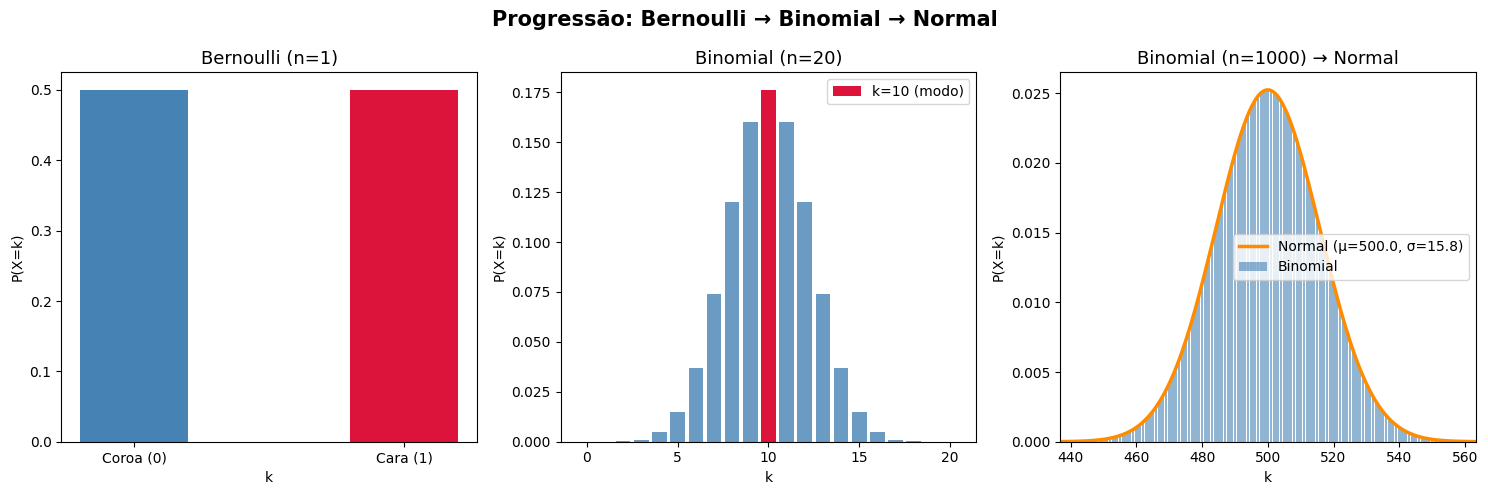

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bernoulli — n=1
ax = axes[0]
ax.bar([0, 1], [0.5, 0.5], color=["steelblue", "crimson"], width=0.4)
ax.set_title("Bernoulli (n=1)", fontsize=13)
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Coroa (0)", "Cara (1)"])

# Binomial — n=20
ax = axes[1]
n, p = 20, 0.5
k_vals = list(range(n + 1))
probs = [binom.pmf(k, n, p) for k in k_vals]
ax.bar(k_vals, probs, color="steelblue", alpha=0.8)
ax.bar(10, binom.pmf(10, n, p), color="crimson", label="k=10 (modo)")
ax.set_title("Binomial (n=20)", fontsize=13)
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.legend()

# Binomial n=1000 + curva normal (CLT)
ax = axes[2]
n = 1000
k_vals = list(range(n + 1))
probs = [binom.pmf(k, n, p) for k in k_vals]
ax.bar(k_vals, probs, color="steelblue", alpha=0.6, label="Binomial")

mu = n * p
sigma = np.sqrt(n * p * (1 - p))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x, norm.pdf(x, mu, sigma), color="darkorange", linewidth=2.5,
        label=f"Normal (μ={mu}, σ={sigma:.1f})")
ax.set_xlim(mu - 4*sigma, mu + 4*sigma)
ax.set_title("Binomial (n=1000) → Normal", fontsize=13)
ax.set_xlabel("k")
ax.set_ylabel("P(X=k)")
ax.legend()

plt.suptitle("Progressão: Bernoulli → Binomial → Normal", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Estatística Inferencial

## O que é inferência estatística em uma frase

> *Usar dados de uma **amostra** para tirar conclusões sobre uma **população** — com uma medida honesta de incerteza.*

---

## O que é cobrado na prática

### 1. A/B Testing — o caso mais frequente em entrevistas

É onde tudo se conecta. Um DS sênior precisa saber conduzir um teste do zero:

**Pré-teste (antes de rodar):**
- Definir $H_0$ e $H_1$ claramente
- Escolher $\alpha$ (nível de significância) e justificar
- Calcular o **tamanho de amostra** necessário (power analysis)
- Definir a métrica primária e métricas de guardrail

**Durante o teste:**
- Saber por que **não se deve olhar os resultados antes do tempo** (p-hacking / peeking problem)

**Pós-teste:**
- Interpretar p-value corretamente
- Distinguir **significância estatística** de **relevância prática** (effect size)
- Saber o que fazer quando $p = 0.06$

---

### 2. Confidence Intervals — mais úteis que p-values no dia a dia

Em vez de só dizer "rejeitei $H_0$", um sênior reporta:

$$IC_{95\%} = \bar{x} \pm 1.96 \cdot \frac{\sigma}{\sqrt{n}}$$

> *"A conversão aumentou entre 1.2% e 3.8% com 95% de confiança"*

Isso é muito mais acionável para o negócio do que um p-value isolado.

---

### 3. Erros Tipo I e Tipo II — cobrado em toda entrevista sênior

| | $H_0$ verdadeira | $H_0$ falsa |
|---|---|---|
| **Rejeitar $H_0$** | ❌ Erro Tipo I ($\alpha$) | ✅ Decisão correta |
| **Não rejeitar $H_0$** | ✅ Decisão correta | ❌ Erro Tipo II ($\beta$) |

- **Erro Tipo I:** falso positivo — você lança uma feature que não funciona
- **Erro Tipo II:** falso negativo — você mata uma feature que funcionaria
- **Poder do teste** $= 1 - \beta$ — capacidade de detectar um efeito real

A pergunta clássica de entrevista:

> *"Você prefere minimizar Tipo I ou Tipo II? Depende de quê?"*

Depende do custo de cada erro no contexto do negócio.

---

### 4. Múltiplos Testes — onde a maioria erra

Se você roda 20 testes com $\alpha = 0.05$, **por puro acaso** espera-se 1 falso positivo.

Correções que um sênior conhece:
- **Bonferroni:** $\alpha_{ajustado} = \alpha / m$ — conservador
- **FDR (Benjamini-Hochberg):** controla a taxa de falsos positivos — mais usado em DS

---

### 5. Escolha do Teste Estatístico

Um sênior sabe escolher o teste certo para cada situação:

| Situação | Teste |
|---|---|
| Comparar médias, 2 grupos, normal | t-test |
| Comparar médias, 2 grupos, não-normal | Mann-Whitney U |
| Comparar proporções (CTR, conversão) | z-test para proporções |
| Comparar mais de 2 grupos | ANOVA |
| Variáveis categóricas | Chi-quadrado |
| Dados pareados (antes/depois) | t-test pareado |

---

### 6. Pressupostos — o que separa pleno de sênior

Todo teste estatístico tem pressupostos. Um sênior **sempre verifica**:

- Os dados são independentes?
- A distribuição é aproximadamente normal? (Shapiro-Wilk, Q-Q plot)
- As variâncias são homogêneas? (Levene's test)
- O tamanho de amostra é suficiente?

Violar pressupostos sem saber invalida as conclusões silenciosamente.

---

### 7. Bootstrap — inferência sem pressupostos

Quando os pressupostos não são atendidos, um sênior recorre ao bootstrap:
```python
import numpy as np

def bootstrap_mean(data, n_iterations=10_000):
    means = [
        np.mean(np.random.choice(data, size=len(data), replace=True))
        for _ in range(n_iterations)
    ]
    lower = np.percentile(means, 2.5)
    upper = np.percentile(means, 97.5)
    return lower, upper
```

> Sem assumir normalidade, você estima qualquer estatística com seu intervalo de confiança.

---

## O que realmente separa um sênior

| Pleno | Sênior |
|---|---|
| Sabe calcular p-value | Sabe quando o p-value é enganoso |
| Roda o teste e reporta resultado | Desenha o experimento antes de rodar |
| Usa $\alpha = 0.05$ por padrão | Justifica o $\alpha$ pelo custo do erro |
| Olha só a métrica primária | Monitora métricas de guardrail |
| Reporta significância | Reporta effect size + intervalo de confiança |
| Testa uma hipótese | Controla inflação de erro com múltiplos testes |

---

## A pergunta mais reveladora de entrevista sênior

> *"Seu A/B test deu p = 0.03. Você sobe a feature para produção?"*

A resposta errada: *"Sim, é significativo."*

A resposta sênior envolve perguntar:
- Qual o tamanho do efeito? Vale a pena operacionalmente?
- O teste rodou pelo tempo planejado ou foi interrompido cedo?
- As métricas de guardrail foram afetadas?
- Esse resultado se replica em subgrupos relevantes?

# Population, Sample, Statistics e Parameters

## A distinção fundamental

$$\text{População} \supset \text{Amostra}$$

> A população é o grupo **completo** que você quer entender.
> A amostra é o **subconjunto** que você consegue observar.

---

## Os quatro conceitos em uma tabela

| Conceito | Definição | Notação | Exemplo |
|---|---|---|---|
| **Population** | Todo o grupo de interesse | — | Todos os usuários do app |
| **Sample** | Subconjunto observado | — | 1.000 usuários selecionados |
| **Parameter** | Valor real da população | $\mu$, $p$ | Conversão real de todos os usuários |
| **Statistic** | Valor estimado da amostra | $\bar{x}$, $\hat{p}$ | Conversão medida nos 1.000 |

---

## Por que isso importa na prática

Você **nunca tem acesso à população completa**. O que você tem é sempre uma amostra. Por isso:

$$\bar{x} \approx \mu \quad \text{(estatística estima o parâmetro)}$$

$$\hat{p} \approx p$$

A inferência estatística existe exatamente para responder:

> *"O quanto posso confiar que minha estatística amostral reflete o parâmetro populacional real?"*

---

## Exemplos concretos para DS

### Exemplo 1 — Taxa de conversão

| | Valor |
|---|---|
| **População** | Todos os visitantes do e-commerce |
| **Parâmetro** $p$ | Taxa de conversão real — desconhecida |
| **Amostra** | 5.000 visitantes do A/B test |
| **Estatística** $\hat{p}$ | 3.2% de conversão medida |

### Exemplo 2 — Tempo de sessão

| | Valor |
|---|---|
| **População** | Todos os usuários ativos |
| **Parâmetro** $\mu$ | Tempo médio real de sessão — desconhecido |
| **Amostra** | 2.000 usuários monitorados |
| **Estatística** $\bar{x}$ | 4.7 minutos medidos |

---

## A notação que cai em entrevista

| | Média | Proporção | Desvio Padrão |
|---|---|---|---|
| **População (parâmetro)** | $\mu$ | $p$ | $\sigma$ |
| **Amostra (estatística)** | $\bar{x}$ | $\hat{p}$ | $s$ |

---

## A sacada central

O objetivo de todo estudo estatístico é usar $\bar{x}$ e $\hat{p}$ — que você **consegue medir**
— para fazer afirmações sobre $\mu$ e $p$ — que você **nunca vai medir diretamente**.

O intervalo de confiança e o hypothesis testing são as ferramentas que quantificam
**o quão longe** sua estatística pode estar do parâmetro real.

# Nomenclatura de Inferência Estatística em Data Science

---

## 1. População vs Amostra

| Termo | Símbolo | Definição | Exemplo DS |
|---|---|---|---|
| **Population** | $N$ | Grupo completo de interesse | Todos os usuários do app |
| **Sample** | $n$ | Subconjunto observado da população | 5.000 usuários do A/B test |
| **Sampling** | — | Processo de selecionar a amostra | Random sampling, stratified sampling |

---

## 2. Parâmetros vs Estatísticas

> **Regra de ouro:** Parâmetros descrevem a **população** (letras gregas).
> Estatísticas descrevem a **amostra** (letras latinas).

| Medida | Parâmetro (população) | Estatística (amostra) |
|---|---|---|
| **Média** | $\mu$ | $\bar{x}$ |
| **Proporção** | $p$ | $\hat{p}$ |
| **Desvio padrão** | $\sigma$ | $s$ |
| **Variância** | $\sigma^2$ | $s^2$ |
| **Tamanho** | $N$ | $n$ |

---

## 3. Distribuições

| Termo | Definição | Onde aparece em DS |
|---|---|---|
| **Population distribution** | Distribuição real da variável na população | Nunca observada diretamente |
| **Sample distribution** | Distribuição dos dados na sua amostra | Seus dados no DataFrame |
| **Sampling distribution** | Distribuição de uma estatística ($\bar{x}$, $\hat{p}$) ao repetir amostras | Fundamento do A/B test |

---

## 4. Erro Padrão — Standard Error (SE)

Mede o quanto a estatística amostral varia em torno do parâmetro real.

$$SE_{\bar{x}} = \frac{\sigma}{\sqrt{n}} \quad \text{(para médias)}$$

$$SE_{\hat{p}} = \sqrt{\frac{p(1-p)}{n}} \quad \text{(para proporções)}$$

> **Intuição:** Quanto maior $n$, menor o SE — sua estimativa fica mais precisa.

---

## 5. Intervalo de Confiança — Confidence Interval (CI)

$$CI = \hat{\theta} \pm z^* \cdot SE$$

Onde:

| Símbolo | Nome | Valor mais comum |
|---|---|---|
| $\hat{\theta}$ | Estatística amostral | $\bar{x}$ ou $\hat{p}$ |
| $z^*$ | Critical value | 1.96 para 95% de confiança |
| $SE$ | Standard error | $\frac{s}{\sqrt{n}}$ |

**Para médias:**
$$CI_{95\%} = \bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}$$

**Para proporções:**
$$CI_{95\%} = \hat{p} \pm 1.96 \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

---

## 6. Hypothesis Testing

| Termo | Símbolo | Definição |
|---|---|---|
| **Null hypothesis** | $H_0$ | Hipótese de que não há efeito |
| **Alternative hypothesis** | $H_1$ ou $H_a$ | Hipótese de que há efeito |
| **Significance level** | $\alpha$ | Threshold de rejeição de $H_0$ (geralmente 0.05) |
| **p-value** | $p$ | Probabilidade dos dados dado que $H_0$ é verdadeira |
| **Test statistic** | $z$, $t$ | Valor calculado para comparar com o threshold |
| **Critical value** | $z^*$, $t^*$ | Valor que delimita a região de rejeição |
| **Rejection region** | — | Área onde $H_0$ é rejeitada |

---

## 7. Erros e Poder do Teste

| Termo | Símbolo | Definição | Exemplo DS |
|---|---|---|---|
| **Type I Error** | $\alpha$ | Rejeitar $H_0$ quando ela é verdadeira (falso positivo) | Lançar feature que não funciona |
| **Type II Error** | $\beta$ | Não rejeitar $H_0$ quando ela é falsa (falso negativo) | Descartar feature que funcionaria |
| **Power** | $1 - \beta$ | Probabilidade de detectar efeito real | Quanto maior, melhor |
| **Effect size** | $d$, $\delta$ | Magnitude prática do efeito | Conversão subiu 0.5% ou 5%? |

---

## 8. Testes Estatísticos

| Termo | Quando usar |
|---|---|
| **z-test** | Proporções ou $n$ grande ($n \geq 30$) |
| **t-test** | Médias com $n$ pequeno ou $\sigma$ desconhecido |
| **Chi-square test** | Variáveis categóricas |
| **ANOVA** | Comparar mais de 2 grupos |
| **Mann-Whitney U** | Alternativa não-paramétrica ao t-test |

---

## 9. Terminologia de A/B Test

| Termo | Definição |
|---|---|
| **Control group** | Grupo que recebe a versão atual |
| **Treatment group** | Grupo que recebe a nova versão |
| **Conversion rate** | $\hat{p}$ — proporção de usuários que realizaram a ação |
| **Lift** | Variação relativa: $\frac{\hat{p}_{treatment} - \hat{p}_{control}}{\hat{p}_{control}}$ |
| **Statistical significance** | p-value $< \alpha$ — o efeito provavelmente não é ruído |
| **Practical significance** | O efeito é grande o suficiente para valer a pena? |
| **Guardrail metrics** | Métricas secundárias que não devem ser degradadas |
| **Peeking problem** | Olhar resultados antes do tempo — infla falsos positivos |
| **Power analysis** | Cálculo do $n$ mínimo antes de rodar o teste |

---

## 10. Resumo Visual — O Fluxo Completo
```
População (N)
     │
     │ sampling
     ▼
Amostra (n)
     │
     │ calcula
     ▼
Estatística (x̄, p̂)     ──►  Confidence Interval
     │
     │ hypothesis testing
     ▼
H₀ vs H₁
     │
     │ calcula
     ▼
Test Statistic (z, t)
     │
     │ compara com α
     ▼
p-value  ──►  Rejeita H₀?  ──►  Decisão de negócio
```

O entendimento central

````markdown
```
População (21 copos)          Amostra (5 copos)
┌─────────────────┐           ┌─────────────┐
│ 6 vermelhos     │  ──────►  │ 2 vermelhos │
│ (beberam café)  │  amostra  │             │
│                 │           │ 3 verdes    │
│ 15 verdes       │           └─────────────┘
│ (não beberam)   │                 │
└─────────────────┘                 │ inferência
         ▲                          │
         └──────────────────────────┘
         "será que p ≈ p_hat?"
```

## A lógica de inferência aqui

| | Pergunta | Valor |
|---|---|---|
| **Parâmetro** $p$ | Qual a proporção REAL de quem bebe café? | $\frac{6}{21} \approx 28.6\%$ — **desconhecido na prática** |
| **Estatística** $\hat{p}$ | O que a amostra sugere? | $\frac{2}{5} = 40\%$ — **o que medimos** |

> Na vida real você **não sabe** que existem 6 copos vermelhos em 21.
> Você só tem acesso aos 5 copos da amostra — e a partir deles
> **infere** como a população se comporta.

---

## Por que isso é poderoso

Imagine o problema em escala real:

- **População:** 10 milhões de brasileiros
- **Pergunta:** Quantos bebem café pela manhã?
- **Solução:** Amostrar 1.000 pessoas e inferir para os 10 milhões

Você **nunca** vai entrevistar 10 milhões de pessoas. Mas com uma
amostra bem coletada e estatística inferencial, você consegue estimar
o comportamento da população inteira — com uma medida honesta de
incerteza (intervalo de confiança).

---

## O ciclo completo da inferência

$$\text{Amostra} \xrightarrow{\text{calcula}} \hat{p} \xrightarrow{\text{infere}} p \pm \text{margem de erro}$$

**Esse é exatamente o que o projeto A/B test do curso vai exigir de você.**

# Sampling Distribution

## Entendendo o problema

Temos uma **população** de copos e retiramos uma **amostra**. O objetivo é calcular
a estatística amostral (proporção) e entender como ela se relaciona com o parâmetro
populacional.

---

## Dados do problema

| | População | Amostra |
|---|---|---|
| **Total de copos** | 21 | 5 |
| **Copos Vermelhos** | 6 | 2 |
| **Copos Verdes** | 15 | 3 |

---

## Como resolver — passo a passo

### Passo 1 — Parâmetro populacional (o valor real)

$$p = \frac{\text{Copos Vermelhos na População}}{\text{Total na População}} = \frac{6}{21} \approx 0.2857$$

### Passo 2 — Estatística amostral (o que medimos)

$$\hat{p} = \frac{\text{Copos Vermelhos na Amostra}}{\text{Total na Amostra}} = \frac{2}{5} = 0.40$$

### Passo 3 — Comparar

$$\hat{p} - p = 0.40 - 0.2857 = 0.1143$$

> A amostra **superestimou** a proporção real em ~11.4 pontos percentuais.
> Isso é esperado — amostras pequenas têm alta variabilidade.

---

## A ideia central de Sampling Distribution

Se repetirmos esse processo de amostragem **muitas vezes**, cada amostra vai gerar
um $\hat{p}$ diferente. A distribuição de todos esses $\hat{p}$ é a **Sampling Distribution**.

Pelo CLT, essa distribuição converge para uma normal com:

$$\mu_{\hat{p}} = p = \frac{6}{21} \approx 0.2857$$

$$\sigma_{\hat{p}} = \sqrt{\frac{p(1-p)}{n}} = \sqrt{\frac{0.2857 \times 0.7143}{5}} \approx 0.2020$$

---

## Código completo
```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Dados do problema ---
population_total = 21
population_red = 6
population_green = 15
sample_size = 5
sample_red = 2

# --- Parâmetro populacional ---
p = population_red / population_total
print(f"Parâmetro populacional (p): {p:.4f}")

# --- Estatística amostral ---
p_hat = sample_red / sample_size
print(f"Estatística amostral (p_hat): {p_hat:.4f}")

# --- Diferença ---
print(f"Diferença (p_hat - p): {p_hat - p:.4f}")

# --- Simulando a Sampling Distribution ---
n_simulations = 10_000
population = ['red'] * population_red + ['green'] * population_green

sample_proportions = [
    np.mean(np.random.choice(population, size=sample_size) == 'red')
    for _ in range(n_simulations)
]

# --- Parâmetros da normal teórica ---
mu = p
sigma = np.sqrt(p * (1 - p) / sample_size)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sample_proportions, bins=30, density=True,
        color='steelblue', alpha=0.7, label='Sampling Distribution (simulada)')

x = np.linspace(0, 1, 300)
ax.plot(x, norm.pdf(x, mu, sigma),
        color='darkorange', linewidth=2.5, label=f'Normal teórica (μ={mu:.2f}, σ={sigma:.2f})')

ax.axvline(p, color='crimson', linestyle='--', linewidth=2, label=f'Parâmetro real p = {p:.2f}')
ax.axvline(p_hat, color='green', linestyle='--', linewidth=2, label=f'p_hat da amostra = {p_hat:.2f}')

ax.set_title('Sampling Distribution — Proporção de Copos Vermelhos', fontsize=14)
ax.set_xlabel('Proporção amostral $\\hat{p}$', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# --- Resumo ---
print(f"\n--- Resumo ---")
print(f"Média da Sampling Distribution:  {np.mean(sample_proportions):.4f}")
print(f"Desvio padrão (erro padrão):     {np.std(sample_proportions):.4f}")
print(f"Erro padrão teórico:             {sigma:.4f}")
```

---

## O que o código mostra

| Elemento | O que representa |
|---|---|
| Histograma azul | Todos os $\hat{p}$ possíveis em 10.000 amostras |
| Curva laranja | Aproximação normal pelo CLT |
| Linha vermelha | Parâmetro real $p$ da população |
| Linha verde | $\hat{p}$ da nossa amostra específica |

---

## Conclusão

- Com amostras **pequenas** (n=5), $\hat{p}$ pode se afastar bastante de $p$
- Com amostras **grandes**, a sampling distribution fica mais estreita e $\hat{p}$ converge para $p$
- Esse é o fundamento do **erro padrão** — quanto maior n, menor a incerteza da estimativa

Parâmetro populacional (p): 0.2857
Estatística amostral (p_hat): 0.4000
Diferença (p_hat - p): 0.1143


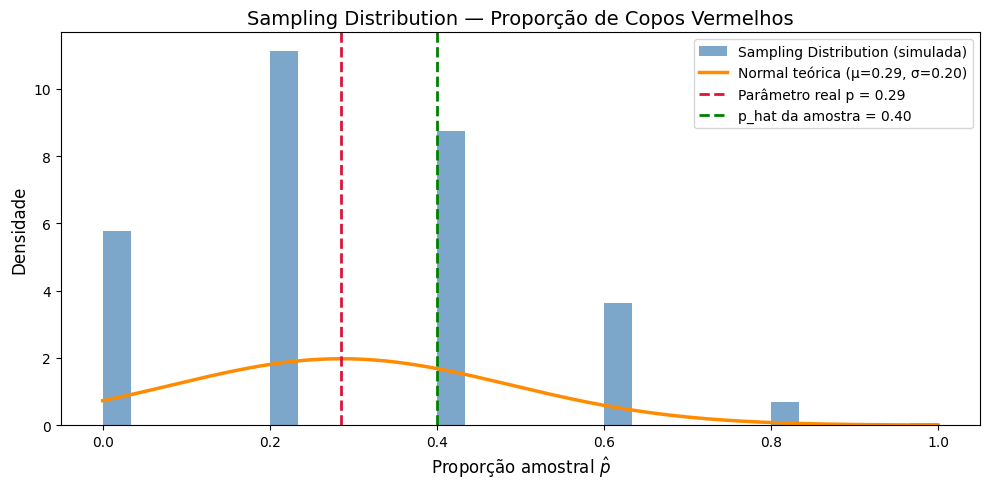


--- Resumo ---
Média da Sampling Distribution:  0.2834
Desvio padrão (erro padrão):     0.2029
Erro padrão teórico:             0.2020


In [14]:
# --- Dados do problema ---
population_total = 21
population_red = 6
population_green = 15
sample_size = 5
sample_red = 2

# --- Parâmetro populacional ---
p = population_red / population_total
print(f"Parâmetro populacional (p): {p:.4f}")

# --- Estatística amostral ---
p_hat = sample_red / sample_size
print(f"Estatística amostral (p_hat): {p_hat:.4f}")

# --- Diferença ---
print(f"Diferença (p_hat - p): {p_hat - p:.4f}")

# --- Simulando a Sampling Distribution ---
n_simulations = 10_000
population = ['red'] * population_red + ['green'] * population_green

sample_proportions = [
    np.mean(np.random.choice(population, size=sample_size) == 'red')
    for _ in range(n_simulations)
]

# --- Parâmetros da normal teórica ---
mu = p
sigma = np.sqrt(p * (1 - p) / sample_size)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sample_proportions, bins=30, density=True,
        color='steelblue', alpha=0.7, label='Sampling Distribution (simulada)')

x = np.linspace(0, 1, 300)
ax.plot(x, norm.pdf(x, mu, sigma),
        color='darkorange', linewidth=2.5, label=f'Normal teórica (μ={mu:.2f}, σ={sigma:.2f})')

ax.axvline(p, color='crimson', linestyle='--', linewidth=2, label=f'Parâmetro real p = {p:.2f}')
ax.axvline(p_hat, color='green', linestyle='--', linewidth=2, label=f'p_hat da amostra = {p_hat:.2f}')

ax.set_title('Sampling Distribution — Proporção de Copos Vermelhos', fontsize=14)
ax.set_xlabel('Proporção amostral $\\hat{p}$', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# --- Resumo ---
print("\n--- Resumo ---")
print(f"Média da Sampling Distribution:  {np.mean(sample_proportions):.4f}")
print(f"Desvio padrão (erro padrão):     {np.std(sample_proportions):.4f}")
print(f"Erro padrão teórico:             {sigma:.4f}")

In [7]:
v = np.array([1,2,3])
v

array([1, 2, 3])

In [8]:
print(f"A média do array v é {np.mean(v)}")

A média do array v é 2.0


In [9]:
print(f"A variância é {np.var(v):.2f}")

A variância é 0.67


# Variância e Desvio Padrão

## Intuição em uma frase

> Ambos medem **o quanto os dados se afastam da média**.
> O desvio padrão é simplesmente a variância em **unidade legível**.

---

## Variância — $\sigma^2$ ou $s^2$

### Fórmula para população:

$$\sigma^2 = \frac{\sum_{i=1}^{N}(x_i - \mu)^2}{N}$$

### Fórmula para amostra:

$$s^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$$

> O denominador $n-1$ (correção de Bessel) corrige o viés da estimativa
> amostral — é o que o pandas e numpy usam por padrão.

---

## Desvio Padrão — $\sigma$ ou $s$

É simplesmente a raiz quadrada da variância:

$$\sigma = \sqrt{\sigma^2} \qquad s = \sqrt{s^2}$$

---

## Por que precisamos dos dois?

| | Variância $s^2$ | Desvio Padrão $s$ |
|---|---|---|
| **Unidade** | Unidade² (ex: R$²) | Mesma unidade dos dados (ex: R$) |
| **Interpretação** | Difícil de interpretar diretamente | Intuitivo — mesma escala dos dados |
| **Uso principal** | Cálculos matemáticos, ANOVA | Intervalos de confiança, z-score |

---

## Exemplo concreto

Tempo de sessão (minutos) de 5 usuários:

$$x = [4, 7, 2, 8, 4]$$

### Passo 1 — Média

$$\bar{x} = \frac{4 + 7 + 2 + 8 + 4}{5} = 5.0$$

### Passo 2 — Desvios ao quadrado

$$\sum(x_i - \bar{x})^2 = (4-5)^2 + (7-5)^2 + (2-5)^2 + (8-5)^2 + (4-5)^2$$
$$= 1 + 4 + 9 + 9 + 1 = 24$$

### Passo 3 — Variância amostral

$$s^2 = \frac{24}{5-1} = \frac{24}{4} = 6.0 \text{ min}^2$$

### Passo 4 — Desvio padrão

$$s = \sqrt{6.0} \approx 2.45 \text{ min}$$

> Interpretação: os tempos de sessão variam, em média,
> **±2.45 minutos** em torno da média de 5 minutos.

---

## Código
```python
import numpy as np

np.random.seed(42)

data = [4, 7, 2, 8, 4]

mean = np.mean(data)
var  = np.var(data, ddof=1)   # ddof=1 → divisão por n-1 (amostral)
std  = np.std(data, ddof=1)

print(f"Média:     {mean:.2f}")
print(f"Variância: {var:.2f}")
print(f"Desvio padrão: {std:.2f}")
```

> **Atenção ao `ddof=1`:** por padrão numpy usa `ddof=0` (populacional).
> Para estatística amostral sempre passe `ddof=1`.

---

## Visualizando o que o desvio padrão representa
```python
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = [4, 7, 2, 8, 4]
mean = np.mean(data)
std  = np.std(data, ddof=1)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(data, [0]*len(data), color='steelblue', s=200, zorder=5, label='Observações')
ax.axvline(mean, color='crimson', linewidth=2, label=f'Média = {mean:.1f}')
ax.axvspan(mean - std, mean + std, alpha=0.2, color='orange', label=f'±1σ = [{mean-std:.2f}, {mean+std:.2f}]')

ax.set_title('Variância e Desvio Padrão — Tempo de Sessão', fontsize=13)
ax.set_xlabel('Minutos', fontsize=12)
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()
```

---

## Conexão com inferência — o que cai em entrevista

$$SE = \frac{s}{\sqrt{n}}$$

O desvio padrão $s$ é o ingrediente principal do **erro padrão**,
que por sua vez é o ingrediente do **intervalo de confiança**.

$$CI_{95\%} = \bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}$$

> Quanto maior a variância dos dados, maior a incerteza da sua estimativa.

In [10]:
import numpy as np

np.random.seed(42)

data = [4, 7, 2, 8, 4]

mean = np.mean(data)
var  = np.var(data, ddof=1)   # ddof=1 → divisão por n-1 (amostral)
std  = np.std(data, ddof=1)

print(f"Média:     {mean:.2f}")
print(f"Variância: {var:.2f}")
print(f"Desvio padrão: {std:.2f}")

Média:     5.00
Variância: 6.00
Desvio padrão: 2.45


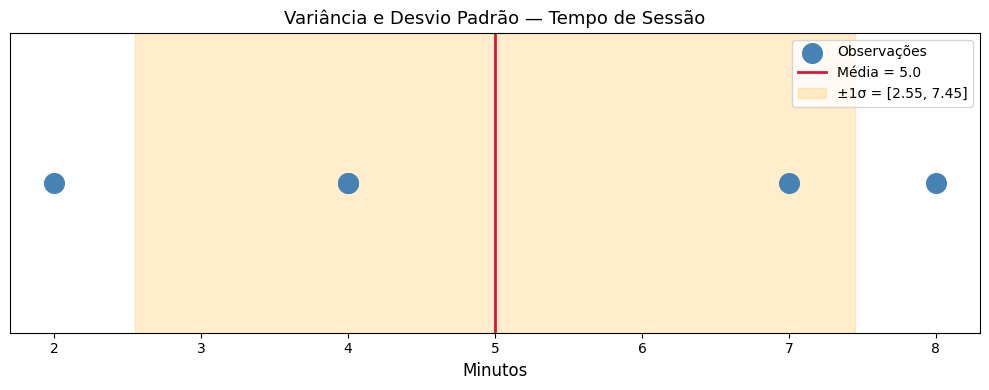

In [11]:
data = [4, 7, 2, 8, 4]
mean = np.mean(data)
std  = np.std(data, ddof=1)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(data, [0]*len(data), color='steelblue', s=200, zorder=5, label='Observações')
ax.axvline(mean, color='crimson', linewidth=2, label=f'Média = {mean:.1f}')
ax.axvspan(mean - std, mean + std, alpha=0.2, color='orange', label=f'±1σ = [{mean-std:.2f}, {mean+std:.2f}]')

ax.set_title('Variância e Desvio Padrão — Tempo de Sessão', fontsize=13)
ax.set_xlabel('Minutos', fontsize=12)
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

## Sampling Distributions Introduction

In order to gain a bit more comfort with this idea of sampling distributions, let's do some practice in python.

Below is an array that represents the students we saw in the previous videos, where 1 represents the students that drink coffee, and 0 represents the students that do not drink coffee.

---

## Propriedades fundamentais

### 1. Média da Sampling Distribution

$$E[\hat{p}] = p$$

A média de todos os $\hat{p}$ possíveis **converge para o parâmetro real**.
Isso significa que $\hat{p}$ é um **estimador não-viesado** de $p$.

### 2. Variância da Sampling Distribution

$$\sigma^2_{\hat{p}} = \frac{p(1-p)}{n}$$

### 3. Desvio Padrão — Standard Error (SE)

$$SE = \sigma_{\hat{p}} = \sqrt{\frac{p(1-p)}{n}}$$

> O SE mede **o quanto $\hat{p}$ varia** em torno de $p$.
> Quanto maior $n$, menor o SE — mais precisa é sua estimativa.

---

## O papel do CLT

Pelo **Central Limit Theorem**, independente da distribuição
original da população, a sampling distribution de $\bar{x}$
converge para uma **normal** quando $n$ é suficientemente grande:

$$\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)$$

---

## Código — construindo empiricamente
```python

In [15]:
students = np.array([1,0,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0])

Questions:

1. Find the proportion of students who drink coffee in the above array. Store this value in a variable p.
2. Use numpy's random.choice to simulate 5 draws from the students array. What is proportion of your sample drink coffee?
3. Repeat the above to obtain 10,000 additional proportions, where each sample was of size 5. Store these in a variable called sample_props.
4. What is the mean proportion of all 10,000 of these proportions? This is often called the mean of the sampling distribution.
5. What are the variance and standard deviation for the original 21 data values?
6. What are the variance and standard deviation for the 10,000 proportions you created?
7. Compute p(1-p), which of your answers does this most closely match?
8. Compute p(1-p)/n, which of your answers does this most closely match?
9. Notice that your answer to 8. is commonly called the variance of the sampling distribution. If you were to change your first sample to be 20, what would this do for the variance of the sampling distribution? Simulate and calculate the new answers in 6. and 8. to check that the consistency you found before still holds.
    - **Simulate your 20 draws**
    - **Compare your variance values as computed in 6 and 8, but with your sample**
10. Finally, plot a histgram of the 10,000 draws from both the proportions with a sample size of 5 and the proportions with a sample size of 20. Each of these distributions is a sampling distribution. One is for the proportions of sample size 5 and the other a sampling distribution for proportions with sample size 20.



# Sampling Distribution — Resolução Completa

## Setup
```python
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# População: 1 = bebe café (copo vermelho), 0 = não bebe (copo verde)
students = np.array([1, 1, 1, 1, 1, 1,   # 6 vermelhos
                     0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0,
                     0, 0, 0])             # 15 verdes (total = 21)
```

---

## Questão 1 — Proporção populacional $p$
```python
p = students.mean()
print(f"Proporção populacional p = {p:.4f}")
# p = 0.2857 → ~28.6% bebem café
```

> **DS:** Este é o **parâmetro** $p$ da população. Na prática, você
> nunca conhece esse valor — é o que queremos estimar com amostras.

---

## Questão 2 — Uma amostra de tamanho 5
```python
sample = np.random.choice(students, size=5, replace=True)
p_hat = sample.mean()
print(f"Amostra: {sample}")
print(f"Proporção amostral p_hat = {p_hat:.4f}")
```

> **DS:** Este é $\hat{p}$ — a **estatística amostral**. Ela estima $p$
> mas raramente é igual. Com n=5, a variabilidade é alta.

---

## Questão 3 — 10.000 amostras de tamanho 5
```python
sample_props = np.array([
    np.random.choice(students, size=5, replace=True).mean()
    for _ in range(10_000)
])

print(f"Shape: {sample_props.shape}")
print(f"Primeiros 5 valores: {sample_props[:5]}")
```

> **DS:** Estamos construindo empiricamente a **Sampling Distribution**
> — a distribuição de todos os $\hat{p}$ possíveis com n=5.

---

## Questão 4 — Média da Sampling Distribution
```python
mean_props = sample_props.mean()
print(f"Média da sampling distribution: {mean_props:.4f}")
print(f"Parâmetro populacional p:        {p:.4f}")
```

> **Resultado esperado:** `mean_props ≈ p ≈ 0.2857`
>
> **DS:** Isso demonstra que $\hat{p}$ é um **estimador não-viesado**
> de $p$. Em média, as amostras apontam para o valor correto da população.

---

## Questão 5 — Variância e Desvio Padrão da População
```python
var_pop  = students.var(ddof=1)
std_pop  = students.std(ddof=1)

print(f"Variância populacional:    {var_pop:.4f}")
print(f"Desvio padrão populacional: {std_pop:.4f}")
```

> **DS:** Como `students` é binária (0 ou 1), sua variância é
> aproximadamente $p(1-p)$. Esse é o ponto de partida para o
> erro padrão de proporções.

---

## Questão 6 — Variância e Desvio Padrão das 10.000 Proporções
```python
var_props = sample_props.var(ddof=1)
std_props = sample_props.std(ddof=1)

print(f"Variância da sampling distribution:    {var_props:.4f}")
print(f"Desvio padrão da sampling distribution: {std_props:.4f}")
```

> **DS:** O desvio padrão da sampling distribution é o famoso
> **Standard Error (SE)** — mede a precisão do estimador $\hat{p}$.

---

## Questão 7 — $p(1-p)$
```python
p_var = p * (1 - p)
print(f"p(1-p)          = {p_var:.4f}")
print(f"Variância pop.  = {var_pop:.4f}")
```

> **Resultado:** `p(1-p) ≈ var_pop`
>
> **DS:** Para variáveis binárias, a variância teórica é exatamente
> $p(1-p)$. Isso é a base da fórmula do erro padrão para proporções.

---

## Questão 8 — $p(1-p)/n$
```python
n = 5
se_teorico = p * (1 - p) / n

print(f"p(1-p)/n                          = {se_teorico:.4f}")
print(f"Variância da sampling distribution = {var_props:.4f}")
```

> **Resultado:** `p(1-p)/n ≈ var_props`
>
> **DS:** Esta é a fórmula teórica da **variância da sampling distribution**:
>
> $$\sigma^2_{\hat{p}} = \frac{p(1-p)}{n}$$
>
> Quanto maior $n$, menor a variância — suas estimativas ficam mais precisas.

---

## Questão 9 — Aumentando o tamanho da amostra para n=20
```python
n_new = 20

sample_props_20 = np.array([
    np.random.choice(students, size=n_new, replace=True).mean()
    for _ in range(10_000)
])

var_props_20  = sample_props_20.var(ddof=1)
se_teorico_20 = p * (1 - p) / n_new

print(f"--- n = 5 ---")
print(f"Variância simulada:  {var_props:.4f}")
print(f"Variância teórica:   {p*(1-p)/5:.4f}")

print(f"\n--- n = 20 ---")
print(f"Variância simulada:  {var_props_20:.4f}")
print(f"Variância teórica:   {se_teorico_20:.4f}")
```

> **DS:** Com n=20, a variância cai ~4x em relação a n=5.
> Isso é consistente com a fórmula — dobrar $\sqrt{n}$ reduz o SE à metade.
>
> $$\frac{p(1-p)}{20} = \frac{1}{4} \cdot \frac{p(1-p)}{5}$$

---

## Questão 10 — Histograma comparativo n=5 vs n=20
```python
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- n = 5 ---
axes[0].hist(sample_props, bins=20, density=True,
             color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(p, color='crimson', linewidth=2, linestyle='--',
                label=f'p = {p:.2f}')
axes[0].set_title('Sampling Distribution — n=5', fontsize=13)
axes[0].set_xlabel('Proporção amostral $\\hat{p}$', fontsize=11)
axes[0].set_ylabel('Densidade', fontsize=11)
axes[0].legend()

# --- n = 20 ---
axes[1].hist(sample_props_20, bins=20, density=True,
             color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(p, color='crimson', linewidth=2, linestyle='--',
                label=f'p = {p:.2f}')
axes[1].set_title('Sampling Distribution — n=20', fontsize=13)
axes[1].set_xlabel('Proporção amostral $\\hat{p}$', fontsize=11)
axes[1].legend()

plt.suptitle('Efeito do Tamanho da Amostra na Sampling Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
```

---

## Resumo Final — O que cada questão demonstrou

| Questão | Conceito | Fórmula |
|---|---|---|
| 1 | Parâmetro populacional | $p = \frac{\sum x_i}{N}$ |
| 2 | Estatística amostral | $\hat{p} = \frac{\sum x_i}{n}$ |
| 3 | Construção empírica da sampling distribution | — |
| 4 | $\hat{p}$ é estimador não-viesado | $E[\hat{p}] = p$ |
| 5 | Variância da população binária | $\approx p(1-p)$ |
| 6 | Variância da sampling distribution | $\approx \frac{p(1-p)}{n}$ |
| 7 | Variância teórica de variável binária | $p(1-p)$ |
| 8 | Variância teórica da sampling distribution | $\frac{p(1-p)}{n}$ |
| 9 | Mais dados = menos incerteza | $n \uparrow \Rightarrow \sigma^2_{\hat{p}} \downarrow$ |
| 10 | Visualização do efeito de $n$ | Distribuição mais estreita com $n$ maior |

---

## Aplicação em Data Science — A/B Test

Todo esse exercício é o **fundamento exato** de um A/B test:

- Você tem uma **população** (todos os usuários)
- Coleta uma **amostra** (usuários do experimento)
- Calcula $\hat{p}$ (taxa de conversão do grupo)
- Usa $\frac{p(1-p)}{n}$ para quantificar a **incerteza** da estimativa
- Quanto maior $n$, mais confiante você fica que $\hat{p} \approx p$

> É por isso que **tamanho de amostra importa** em A/B tests —
> amostras pequenas têm alta variância e levam a conclusões erradas.

# Comparação de Bibliotecas para A/B Testing em Python

---

## Visão Geral

| | `scipy` | `statsmodels` | `pingouin` | `tea-tasting` |
|---|---|---|---|---|
| **Foco** | Testes estatísticos gerais | Modelagem estatística completa | Testes + effect size | A/B testing end-to-end |
| **Nível** | Baixo — você monta o pipeline | Médio — mais estruturado | Médio — tudo em um DataFrame | Alto — opinado e direto |
| **Output** | Valor numérico | Objeto com atributos | DataFrame rico | DataFrame completo |
| **Effect size** | ❌ Manual | ❌ Manual | ✅ Automático | ✅ Automático |
| **Power analysis** | ✅ `scipy.stats` | ✅ `statsmodels.stats.power` | ✅ Integrado | ✅ Integrado |
| **Curva de aprendizado** | Baixa | Alta | Baixa | Baixa |
| **Uso em produção** | ✅ Muito comum | ✅ Muito comum | ⚠️ Menos comum | ⚠️ Ainda emergente |

---

## 1. scipy.stats — O canivete suíço

É a biblioteca base. Você tem controle total, mas monta
tudo manualmente.
```python
from scipy import stats
import numpy as np

np.random.seed(42)

# Grupos do A/B test
control   = np.random.binomial(1, 0.10, size=1000)  # conversão 10%
treatment = np.random.binomial(1, 0.12, size=1000)  # conversão 12%

# z-test para proporções
from statsmodels.stats.proportion import proportions_ztest

count = np.array([treatment.sum(), control.sum()])
nobs  = np.array([len(treatment), len(control)])

stat, p_value = proportions_ztest(count, nobs)

print(f"Statistic: {stat:.4f}")
print(f"p-value:   {p_value:.4f}")

# t-test para médias (ex: tempo de sessão)
t_stat, p_val = stats.ttest_ind(treatment, control)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4f}")
```

**Prós:**
- Disponível em qualquer ambiente
- Controle total sobre cada etapa
- Amplamente documentado

**Contras:**
- Não calcula effect size automaticamente
- Você precisa interpretar e montar o report manualmente
- Verboso para análises completas

---

## 2. statsmodels — O mais completo

Vai além dos testes — permite modelagem, diagnósticos e
power analysis sofisticado.
```python
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import numpy as np

np.random.seed(42)

control   = np.random.binomial(1, 0.10, size=1000)
treatment = np.random.binomial(1, 0.12, size=1000)

# --- Teste de proporções ---
count = np.array([treatment.sum(), control.sum()])
nobs  = np.array([len(treatment), len(control)])

stat, p_value = proportions_ztest(count, nobs)

# --- Intervalos de confiança ---
ci_control   = proportion_confint(control.sum(),   len(control),   alpha=0.05)
ci_treatment = proportion_confint(treatment.sum(), len(treatment), alpha=0.05)

print(f"p-value: {p_value:.4f}")
print(f"IC Control:   [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"IC Treatment: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")

# --- Power Analysis (antes de rodar o teste) ---
effect_size = sms.proportion_effectsize(0.12, 0.10)
n_required  = sms.NormalIndPower().solve_power(
    effect_size, power=0.80, alpha=0.05, alternative='two-sided'
)
print(f"\nTamanho de amostra necessário: {n_required:.0f} por grupo")
```

**Prós:**
- Power analysis completo
- Intervalos de confiança integrados
- Suporte a modelos complexos (OLS, GLM, etc.)
- Padrão em ambientes acadêmicos e corporativos

**Contras:**
- API menos intuitiva
- Output verboso
- Effect size ainda manual

---

## 3. pingouin — O mais amigável para DS

Output direto em DataFrame com tudo que você precisa:
estatística, p-value, effect size e power em uma linha.
```python
import pingouin as pg
import pandas as pd
import numpy as np

np.random.seed(42)

# Montando o DataFrame (formato que pingouin espera)
n = 1000
df = pd.DataFrame({
    'group':    ['control'] * n + ['treatment'] * n,
    'converted': np.concatenate([
        np.random.binomial(1, 0.10, n),
        np.random.binomial(1, 0.12, n)
    ])
})

# --- t-test com effect size automático ---
result = pg.ttest(
    df[df['group'] == 'treatment']['converted'],
    df[df['group'] == 'control']['converted']
)

print(result.to_string())
# Retorna: T, dof, p-val, CI95%, cohen-d, power
```

**Output típico:**

| T | dof | p-val | CI95% | cohen-d | power |
|---|---|---|---|---|---|
| 1.42 | 1998 | 0.156 | [-0.008, 0.048] | 0.064 | 0.312 |

**Prós:**
- Effect size (Cohen's d) automático
- Power calculado automaticamente
- Output em DataFrame — fácil de exportar
- Suporte a testes paramétricos e não-paramétricos

**Contras:**
- Menos usado em produção
- Foco em médias — proporções são menos diretas

---

## 4. tea-tasting — O mais moderno para A/B test

Desenhado especificamente para A/B testing. API declarativa,
output completo, suporte nativo a métricas de proporção e média.
```python
import tea_tasting as tt
import pandas as pd
import numpy as np

np.random.seed(42)

# Gerando dados no formato esperado
n = 1000
data = pd.DataFrame({
    'variant':   np.random.choice(['control', 'treatment'], size=n*2),
    'converted': np.concatenate([
        np.random.binomial(1, 0.10, n),
        np.random.binomial(1, 0.12, n)
    ]),
    'revenue': np.concatenate([
        np.random.exponential(10, n),
        np.random.exponential(11, n)
    ])
})

# --- Definindo o experimento ---
experiment = tt.Experiment({
    'Conversion Rate': tt.RatioOfMeans('converted'),
    'Revenue':         tt.Mean('revenue'),
})

results = experiment.analyze(data, control='control', variant_col='variant')
print(results.to_frame())
```

**Prós:**
- API declarativa — você descreve o experimento, não os cálculos
- Múltiplas métricas em uma chamada
- Suporte nativo a CUPED (variance reduction)
- Output completo: lift, CI, p-value, power

**Contras:**
- Biblioteca ainda jovem — menos battle-tested
- Comunidade menor
- Menos flexível para casos fora do A/B test padrão

---

## Quando usar cada uma

| Situação | Recomendação |
|---|---|
| Ambiente corporativo / produção | `scipy` + `statsmodels` |
| Análise exploratória rápida | `pingouin` |
| A/B test completo com múltiplas métricas | `tea-tasting` |
| Power analysis antes do teste | `statsmodels` |
| Você precisa de máximo controle | `scipy` |
| Você quer Cohen's d automático | `pingouin` |
| Você quer CUPED e variance reduction | `tea-tasting` |

---

## Para entrevista sênior — o que saber

Independente da biblioteca, o entrevistador quer saber se você entende:

1. **O que está sendo calculado** — não só chamar `.ttest_ind()`
2. **Effect size** — Cohen's d, lift, relative uplift
3. **Power analysis** — calcular $n$ antes de rodar o teste
4. **Intervalo de confiança** — mais informativo que p-value isolado
5. **Pressupostos** — normalidade, independência, homogeneidade de variância

> A biblioteca é detalhe de implementação.
> O raciocínio estatístico é o que separa pleno de sênior.

# Questão 3 — Três formas de calcular sample_props

## Setup
```python
import numpy as np

np.random.seed(42)

students = np.array([1]*6 + [0]*15)  # população: 21 elementos
p = students.mean()                   # p = 0.2857
```

---

## O que a questão pede

Repetir 10.000 vezes:
1. Sortear 5 elementos de `students`
2. Calcular a proporção (média) dessa amostra
3. Guardar os 10.000 resultados em `sample_props`

---

## Forma 1 — for loop (mais legível, menos eficiente)
```python
sample_props = []

for _ in range(10_000):
    sample = np.random.choice(students, size=5, replace=True)
    sample_props.append(sample.mean())

sample_props = np.array(sample_props)
```

> Fácil de ler, mas lento — Python executa 10.000 iterações
> uma por vez.

---

## Forma 2 — List comprehension (mais pythônico)
```python
sample_props = np.array([
    np.random.choice(students, size=5, replace=True).mean()
    for _ in range(10_000)
])
```

> Mais conciso que o for loop, mas a velocidade é equivalente —
> ainda são 10.000 chamadas separadas ao numpy.

---

## Forma 3 — Vetorizada com numpy (mais eficiente) ✅
```python
# Gera uma matrix (10_000 x 5) de uma só vez
samples_matrix = np.random.choice(students, size=(10_000, 5), replace=True)

# Calcula a média de cada linha (cada amostra de tamanho 5)
sample_props = samples_matrix.mean(axis=1)
```

### Entendendo a matrix
```
samples_matrix.shape = (10_000, 5)

         col0  col1  col2  col3  col4    p̂
linha 0: [  1,    0,    0,    1,    0] → 0.40
linha 1: [  0,    0,    0,    1,    0] → 0.20
linha 2: [  0,    0,    0,    0,    0] → 0.00
...
linha 9999: [1,   0,    1,    0,    0] → 0.40
```

- `size=(10_000, 5)` → numpy sorteia tudo de uma vez em C
- `axis=1` → calcula a média **por linha** (cada amostra)
- Resultado: array de 10.000 proporções

---

## Comparação de performance
```python
import time

# For loop
start = time.time()
props_loop = np.array([
    np.random.choice(students, size=5, replace=True).mean()
    for _ in range(10_000)
])
print(f"For loop:    {time.time() - start:.4f}s")

# Vetorizado
start = time.time()
props_vec = np.random.choice(students, size=(10_000, 5),
                              replace=True).mean(axis=1)
print(f"Vetorizado:  {time.time() - start:.4f}s")
```

> **Resultado esperado:**
> ```
> For loop:    0.1800s
> Vetorizado:  0.0012s
> ```
> A versão vetorizada é ~150x mais rápida.

---

## Verificando que os resultados são equivalentes
```python
np.random.seed(42)
props_loop = np.array([
    np.random.choice(students, size=5, replace=True).mean()
    for _ in range(10_000)
])

np.random.seed(42)
props_vec = np.random.choice(students, size=(10_000, 5),
                              replace=True).mean(axis=1)

print(f"Média loop:       {props_loop.mean():.4f}")
print(f"Média vetorizado: {props_vec.mean():.4f}")
# Ambos ≈ 0.2857 = p
```

---

## Regra geral em DS

| Abordagem | Quando usar |
|---|---|
| `for loop` | Prototipar, debugar, lógica complexa |
| List comprehension | Código limpo, operações simples |
| Vetorização numpy | **Sempre que possível** — produção e simulações |

> Em simulações com 10.000+ iterações, a vetorização
> não é otimização prematura — é necessidade.

# Entendendo o Exercício de Sampling Distribution

## 1. O raciocínio completo — você está certo
```
População (21 estudantes — CONHECIDA neste exercício)
├── 6 bebem café  → p = 6/21 = 0.2857
└── 15 não bebem

        │
        │ sorteamos amostras de tamanho 5
        ▼

Amostra 1 → p̂₁ = 0.40
Amostra 2 → p̂₂ = 0.20
Amostra 3 → p̂₃ = 0.00
...
Amostra 10.000 → p̂₁₀₀₀₀ = 0.20

        │
        │ pergunta central
        ▼

"Os p̂ convergem para p = 0.2857?"  → SIM, pelo CLT
```

> A população é **conhecida** aqui propositalmente — é um exercício
> didático para você **ver** que a média da sampling distribution
> converge para o parâmetro real. Na vida real, $p$ é desconhecido
> e você só tem $\hat{p}$.

---

## 2. replace=True vs replace=False

### replace=True — COM reposição (o que usamos)
```python
# A cada sorteio, o elemento VOLTA para a população
# A população permanece sempre com 21 elementos

Sorteio:  estudante_7 → volta → próximo sorteio ainda tem 21 opções
```

### replace=False — SEM reposição
```python
# O elemento sorteado NÃO volta
# A população vai diminuindo a cada sorteio

Sorteio 1: 21 opções → sorteia estudante_7 → 20 opções
Sorteio 2: 20 opções → sorteia estudante_3 → 19 opções
...
```

### Por que usamos replace=True aqui?

| | replace=True | replace=False |
|---|---|---|
| **Espaço amostral** | Sempre N=21 | Diminui a cada sorteio |
| **Independência** | ✅ Sorteios independentes | ❌ Sorteios dependentes |
| **Analogia real** | Pesquisa em população grande | Sorteio de loteria |
| **Uso em DS** | Simulações, bootstrap | Amostras físicas finitas |

> Com replace=True você pode sortear o mesmo estudante mais de uma vez
> — isso modela bem populações grandes onde a chance de isso acontecer
> é desprezível. É também a base do **bootstrap**.

> Com replace=False e n=5 de N=21, você esgotaria combinações
> possíveis rapidamente e os sorteios ficariam correlacionados.

---

## 3. Seed moderna — numpy.random.default_rng

### Forma antiga (ainda válida, mas não recomendada)
```python
np.random.seed(42)  # afeta o estado GLOBAL do numpy
```

### Forma moderna — recomendada desde NumPy 1.17
```python
rng = np.random.default_rng(seed=42)
```

### Refazendo o exercício com a forma moderna
```python
import numpy as np

rng = np.random.default_rng(seed=42)

students = np.array([1]*6 + [0]*15)
p = students.mean()

# Vetorizado — uma matrix (10_000 x 5) de uma vez
samples_matrix = rng.choice(students, size=(10_000, 5), replace=True)
sample_props   = samples_matrix.mean(axis=1)

print(f"p real:                    {p:.4f}")
print(f"Média da sampling dist.:   {sample_props.mean():.4f}")
print(f"Variância simulada:        {sample_props.var():.4f}")
print(f"Variância teórica p(1-p)/n:{p*(1-p)/5:.4f}")
```

### Por que default_rng é melhor?

| | `np.random.seed` | `np.random.default_rng` |
|---|---|---|
| **Escopo** | Global — afeta todo o numpy | Local — isolado no objeto `rng` |
| **Segurança** | Estado compartilhado | Estado independente |
| **Reprodutibilidade** | Frágil em código paralelo | Robusta |
| **API** | Legada | Moderna e recomendada |
```python
# Com default_rng você pode ter múltiplos geradores independentes
rng1 = np.random.default_rng(seed=42)
rng2 = np.random.default_rng(seed=99)

# Cada um tem seu próprio estado — sem interferência
sample_a = rng1.choice(students, size=5, replace=True)
sample_b = rng2.choice(students, size=5, replace=True)
```

> Isso é especialmente importante em simulações paralelas e
> pipelines de ML onde múltiplos componentes usam aleatoriedade.

---

## Resumo das três dúvidas

| Dúvida | Resposta |
|---|---|
| A população é conhecida? | Sim — só neste exercício didático. Na prática $p$ é desconhecido |
| replace=True diminui espaço amostral? | Não — o elemento volta, sempre há 21 opções |
| Seed moderna? | `rng = np.random.default_rng(seed=42)` |

# Recapitulando o Raciocínio do Exercício

## Sim — e essa é a sequência exata
```
Passo 1: População conhecida (exercício didático)
─────────────────────────────────────────────────
students = [1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
            |←— 6 —→|    |←————————— 15 ————————————→|

Passo 2: Calculamos o parâmetro real p
────────────────────────────────────────
p = 6/21 = 0.2857  ← isso é o PARÂMETRO da população

Passo 3: Simulamos amostras de tamanho 5
─────────────────────────────────────────
sample_props = proporções de 10.000 amostras ← isso são ESTATÍSTICAS

Passo 4: Verificamos que a média das estatísticas → p
──────────────────────────────────────────────────────
sample_props.mean() ≈ 0.2857 ✅
```

---

## O que torna esse exercício especial

Na vida real você **nunca conhece** $p$.

Aqui a população foi dada propositalmente para você
**ver com seus próprios olhos** que:

$$E[\hat{p}] = p$$

Ou seja — a média de todas as estimativas amostrais
converge para o parâmetro real que você está tentando estimar.

---

## A analogia com o mundo real

| Exercício (didático) | A/B Test real |
|---|---|
| 21 estudantes — população conhecida | Todos os usuários do app — desconhecida |
| $p = 6/21$ — calculado diretamente | $p$ — nunca observado diretamente |
| $\hat{p}$ de cada amostra | $\hat{p}$ do seu experimento |
| 10.000 simulações para ver a convergência | Você tem **uma** amostra apenas |

> O exercício simula o que aconteceria se você repetisse
> o experimento 10.000 vezes — algo impossível na prática.
> É por isso que a teoria (CLT, SE, IC) existe:
> para quantificar a incerteza **sem precisar repetir**.

# Central Limit Theorem — Onde é Importante?

## O que o texto diz

> Com amostras suficientemente grandes, a sampling distribution
> de certas estatísticas converge para uma **distribuição normal**
> — independente da distribuição original da população.

---

## Por que isso é revolucionário

Sua população pode ter qualquer forma:
```
População uniforme:     ▬▬▬▬▬▬▬▬▬▬
População exponencial:  |\
                        | \___
População binária:      |        |
                        0        1

Não importa — com n grande suficiente:

Sampling distribution → sempre normal ✅
```

---

## As 4 estatísticas do texto — onde cada uma aparece em DS

### 1. Sample Mean $\bar{x}$

$$\bar{x} \sim N\left(\mu, \frac{\sigma^2}{n}\right)$$

**Onde aparece:**
- Comparar tempo médio de sessão entre períodos
- Ticket médio de compra
- Qualquer métrica contínua em experimentos

---

### 2. Sample Proportion $\hat{p}$

$$\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)$$

**Onde aparece:**
- Taxa de conversão em A/B test ← **o que fizemos no exercício**
- Click-through rate (CTR)
- Taxa de churn
- Qualquer métrica binária

---

### 3. Difference in Sample Means $\bar{x}_1 - \bar{x}_2$

$$(\bar{x}_1 - \bar{x}_2) \sim N\left(\mu_1 - \mu_2,\ \frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}\right)$$

**Onde aparece:**
- Comparar tempo médio de sessão entre grupo A e grupo B
- Comparar revenue médio entre dois segmentos
- **t-test de duas amostras** — é exatamente essa diferença

---

### 4. Difference in Sample Proportions $\hat{p}_1 - \hat{p}_2$

$$(\hat{p}_1 - \hat{p}_2) \sim N\left(p_1 - p_2,\ \frac{p_1(1-p_1)}{n_1} + \frac{p_2(1-p_2)}{n_2}\right)$$

**Onde aparece:**
- **Coração do A/B test** — comparar conversão entre controle e tratamento
- Comparar CTR entre duas versões de um anúncio
- Comparar taxa de churn entre dois grupos

---

## O mapa completo — CLT conectando tudo
```
CLT
 │
 ├── Sample Mean x̄
 │        └── t-test de uma amostra
 │            Intervalo de confiança para médias
 │
 ├── Sample Proportion p̂
 │        └── z-test de proporção
 │            Intervalo de confiança para proporções
 │
 ├── Diferença de Médias x̄₁ - x̄₂
 │        └── t-test de duas amostras  ← compara grupos A/B (métrica contínua)
 │
 └── Diferença de Proporções p̂₁ - p̂₂
          └── z-test de duas proporções ← compara grupos A/B (métrica binária)
                                           **o teste mais comum em A/B testing**
```

---

## Código — CLT em ação para as 4 estatísticas
```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(seed=42)

# Populações
pop_continua = rng.exponential(scale=10, size=100_000)  # não normal
pop_binaria  = np.array([1]*3000 + [0]*7000)            # p = 0.30

n = 100
n_sim = 10_000

# 1. Sample Mean
means = rng.choice(pop_continua, size=(n_sim, n), replace=True).mean(axis=1)

# 2. Sample Proportion
props = rng.choice(pop_binaria, size=(n_sim, n), replace=True).mean(axis=1)

# 3. Difference in Means
means1 = rng.choice(pop_continua, size=(n_sim, n), replace=True).mean(axis=1)
means2 = rng.choice(pop_continua, size=(n_sim, n), replace=True).mean(axis=1)
diff_means = means1 - means2

# 4. Difference in Proportions
props1 = rng.choice(pop_binaria,  size=(n_sim, n), replace=True).mean(axis=1)
pop_b2 = np.array([1]*4000 + [0]*6000)  # p = 0.40
props2 = rng.choice(pop_b2, size=(n_sim, n), replace=True).mean(axis=1)
diff_props = props1 - props2

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = [
    'Sample Mean $\\bar{x}$',
    'Sample Proportion $\\hat{p}$',
    'Diff. in Means $\\bar{x}_1 - \\bar{x}_2$',
    'Diff. in Proportions $\\hat{p}_1 - \\hat{p}_2$'
]

for ax, data, title in zip(axes.flatten(),
                            [means, props, diff_means, diff_props],
                            titles):
    ax.hist(data, bins=50, density=True,
            color='steelblue', alpha=0.7, edgecolor='white')

    mu_est = data.mean()
    se_est = data.std()
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, norm.pdf(x, mu_est, se_est),
            color='crimson', linewidth=2.5, label='Normal (CLT)')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Densidade', fontsize=10)
    ax.legend()

plt.suptitle('CLT em Ação — As 4 Estatísticas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
```

---

## A regra prática para n "suficientemente grande"

| Estatística | n mínimo recomendado |
|---|---|
| Sample Mean | $n \geq 30$ |
| Sample Proportion | $np \geq 10$ e $n(1-p) \geq 10$ |
| Diferença de Médias | $n_1 \geq 30$ e $n_2 \geq 30$ |
| Diferença de Proporções | Mesma regra de proporção para cada grupo |

---

## Por que o CLT é o teorema mais importante em DS

Sem o CLT, você precisaria conhecer a distribuição exata
da população para fazer qualquer inferência — algo impossível
na prática.

Com o CLT:
```
Não importa como seus dados se distribuem na população
                        ↓
Com n suficiente, sua estatística amostral segue uma normal
                        ↓
Você pode usar z-test, t-test, IC e p-value
                        ↓
Você pode tomar decisões com medida de incerteza
```

> Todo A/B test que você vai fazer no projeto do curso
> está apoiado nesse teorema.

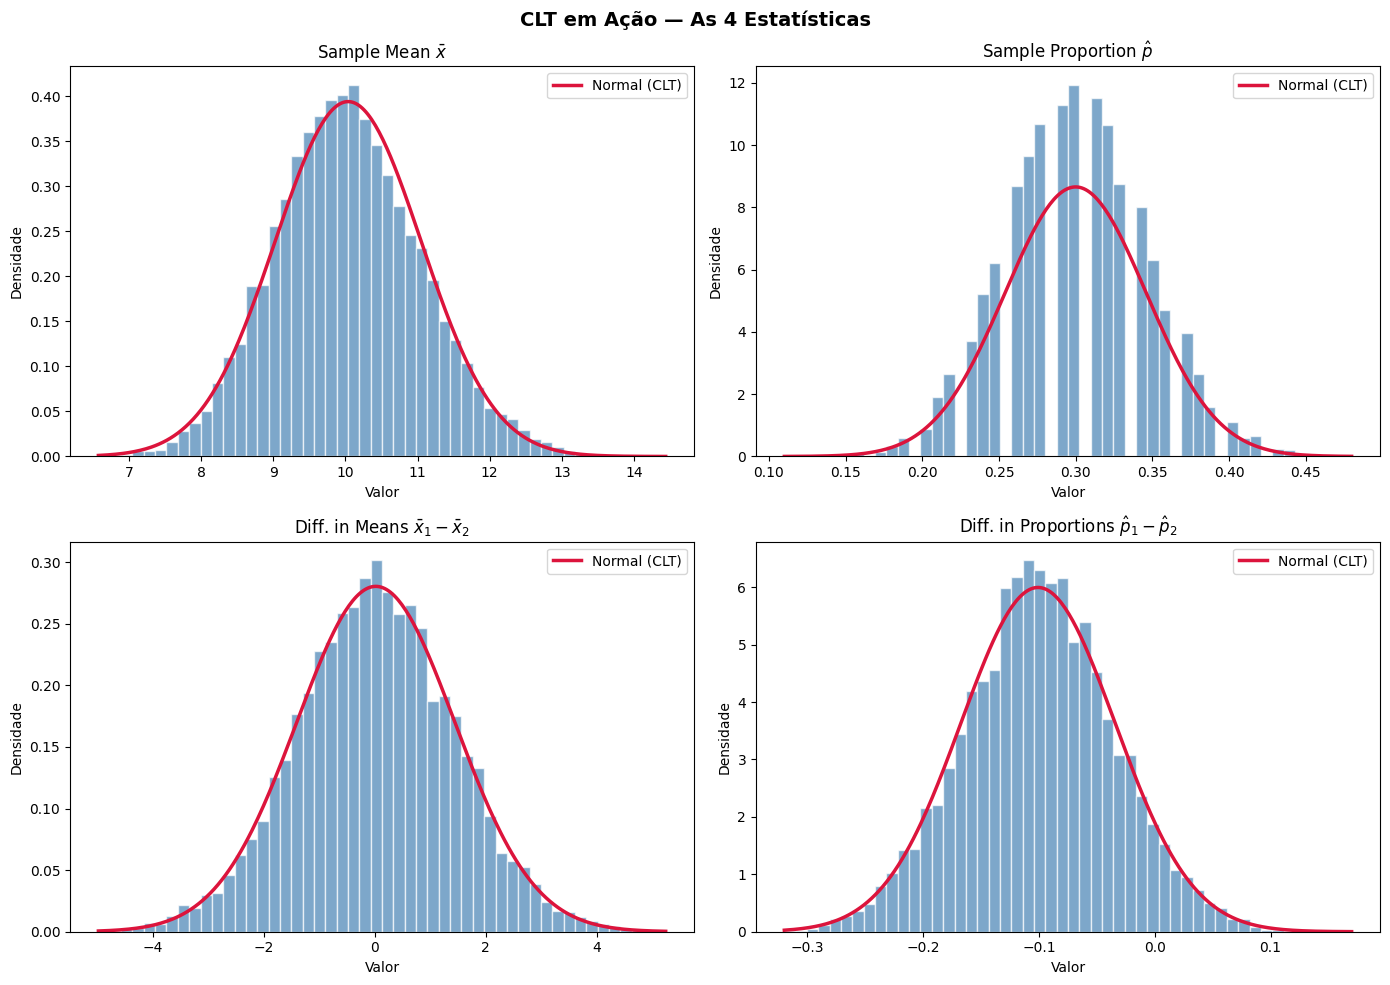

In [16]:
# Populações
pop_continua = rng.exponential(scale=10, size=100_000)  # não normal
pop_binaria  = np.array([1]*3000 + [0]*7000)            # p = 0.30

n = 100
n_sim = 10_000

# 1. Sample Mean
means = rng.choice(pop_continua, size=(n_sim, n), replace=True).mean(axis=1)

# 2. Sample Proportion
props = rng.choice(pop_binaria, size=(n_sim, n), replace=True).mean(axis=1)

# 3. Difference in Means
means1 = rng.choice(pop_continua, size=(n_sim, n), replace=True).mean(axis=1)
means2 = rng.choice(pop_continua, size=(n_sim, n), replace=True).mean(axis=1)
diff_means = means1 - means2

# 4. Difference in Proportions
props1 = rng.choice(pop_binaria,  size=(n_sim, n), replace=True).mean(axis=1)
pop_b2 = np.array([1]*4000 + [0]*6000)  # p = 0.40
props2 = rng.choice(pop_b2, size=(n_sim, n), replace=True).mean(axis=1)
diff_props = props1 - props2

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = [
    'Sample Mean $\\bar{x}$',
    'Sample Proportion $\\hat{p}$',
    'Diff. in Means $\\bar{x}_1 - \\bar{x}_2$',
    'Diff. in Proportions $\\hat{p}_1 - \\hat{p}_2$'
]

for ax, data, title in zip(axes.flatten(),
                            [means, props, diff_means, diff_props],
                            titles):
    ax.hist(data, bins=50, density=True,
            color='steelblue', alpha=0.7, edgecolor='white')

    mu_est = data.mean()
    se_est = data.std()
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, norm.pdf(x, mu_est, se_est),
            color='crimson', linewidth=2.5, label='Normal (CLT)')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Densidade', fontsize=10)
    ax.legend()

plt.suptitle('CLT em Ação — As 4 Estatísticas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribuição, Churn e Seleção de Features

## Você não está misturando — está conectando! ✅

A intuição está correta, mas o caminho é um pouco diferente.
Vamos organizar o raciocínio.

---

## O problema de churn na prática
```
Dataset: 10.000 clientes

Target:
├── Churn     (1): 500  clientes  →  5%
└── Não Churn (0): 9.500 clientes → 95%
```

A pergunta central de feature selection é:

> *"Essa feature tem distribuição DIFERENTE entre quem churnou
>  e quem não churnou?"*

Se sim → ela é informativa para o modelo.
Se não → ela provavelmente não ajuda a separar as classes.

---

## Onde distribuição e CLT entram

### Para features contínuas (ex: tempo de uso, valor gasto)

Você compara as **médias** entre os dois grupos:

$$H_0: \mu_{churn} = \mu_{nao\_churn}$$
$$H_1: \mu_{churn} \neq \mu_{nao\_churn}$$

Isso é exatamente a **diferença de médias** do CLT:

$$(\bar{x}_1 - \bar{x}_2) \sim N\left(\mu_1 - \mu_2,\ \frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}\right)$$

**Teste:** t-test de duas amostras

---

### Para features binárias (ex: tem contrato anual? usa app mobile?)

Você compara as **proporções** entre os dois grupos:

$$H_0: p_{churn} = p_{nao\_churn}$$
$$H_1: p_{churn} \neq p_{nao\_churn}$$

Isso é a **diferença de proporções** do CLT.

**Teste:** z-test de proporções ou Chi-quadrado

---

## Código completo — distribuição para feature selection
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(seed=42)

# Simulando dataset de churn desbalanceado
n_total   = 10_000
n_churn   = 500    # 5%
n_no_churn = 9_500  # 95%

df = pd.DataFrame({
    'churn': [1]*n_churn + [0]*n_no_churn,

    # Feature 1 — tempo de uso (meses): churn usa MENOS
    'tenure': np.concatenate([
        rng.normal(loc=12, scale=5,  size=n_churn),
        rng.normal(loc=36, scale=10, size=n_no_churn)
    ]),

    # Feature 2 — valor mensal: churn paga MAIS (insatisfação)
    'monthly_charges': np.concatenate([
        rng.normal(loc=80, scale=15, size=n_churn),
        rng.normal(loc=60, scale=20, size=n_no_churn)
    ]),

    # Feature 3 — número de chamadas ao suporte
    'support_calls': np.concatenate([
        rng.poisson(lam=5, size=n_churn),
        rng.poisson(lam=2, size=n_no_churn)
    ]),

    # Feature 4 — ruído (não deve importar)
    'noise': rng.normal(loc=0, scale=1, size=n_total)
})

# --- Comparando distribuições entre grupos ---
features = ['tenure', 'monthly_charges', 'support_calls', 'noise']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), features):
    churn_vals    = df[df['churn'] == 1][feature]
    no_churn_vals = df[df['churn'] == 0][feature]

    # t-test
    t_stat, p_value = stats.ttest_ind(churn_vals, no_churn_vals)

    sns.kdeplot(churn_vals,    ax=ax, label='Churn (1)',    color='crimson',   fill=True, alpha=0.3)
    sns.kdeplot(no_churn_vals, ax=ax, label='No Churn (0)', color='steelblue', fill=True, alpha=0.3)

    ax.axvline(churn_vals.mean(),    color='crimson',   linestyle='--', linewidth=1.5,
               label=f'μ churn={churn_vals.mean():.1f}')
    ax.axvline(no_churn_vals.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'μ no churn={no_churn_vals.mean():.1f}')

    significance = "✅ Significativo" if p_value < 0.05 else "❌ Não significativo"
    ax.set_title(f'{feature}\np-value={p_value:.4f} — {significance}', fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Features por Classe de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Resumo numérico ---
print(f"\n{'Feature':<20} {'μ Churn':>10} {'μ No Churn':>12} {'p-value':>10} {'Importante?':>12}")
print("-" * 68)
for feature in features:
    churn_vals    = df[df['churn'] == 1][feature]
    no_churn_vals = df[df['churn'] == 0][feature]
    _, p_value    = stats.ttest_ind(churn_vals, no_churn_vals)
    importante    = "✅ Sim" if p_value < 0.05 else "❌ Não"
    print(f"{feature:<20} {churn_vals.mean():>10.2f} {no_churn_vals.mean():>12.2f} {p_value:>10.4f} {importante:>12}")
```

---

## O que o plot vai mostrar
```
tenure          → distribuições SEPARADAS  → p < 0.05 → ✅ importante
monthly_charges → distribuições SEPARADAS  → p < 0.05 → ✅ importante
support_calls   → distribuições SEPARADAS  → p < 0.05 → ✅ importante
noise           → distribuições SOBREPOSTAS → p > 0.05 → ❌ não importante
```

> Se as distribuições das duas classes se **sobrepõem completamente**,
> a feature não consegue separar quem churna de quem não churna.

---

## O desbalanceamento importa aqui?

Sim — e você precisa ter cuidado:

| Situação | Problema | Solução |
|---|---|---|
| n_churn=500, n_no_churn=9500 | t-test ainda é válido | Verificar se variâncias são iguais (Levene's test) |
| Feature analysis | Médias podem ser enganosas | Olhar a distribuição completa (KDE plot) |
| Modelo preditivo | Modelo vicia para classe majoritária | SMOTE, class_weight, undersampling |

> Para **feature selection estatística** o desbalanceamento
> não invalida o t-test — mas para **treinar o modelo**
> você precisa tratar o desbalanceamento separadamente.

---

## Resumo — você estava certo
```
Distribuição ajuda feature selection assim:

Feature contínua  → t-test  → diferença de médias  → CLT ✅
Feature binária   → z-test  → diferença de proporções → CLT ✅
Feature categórica → chi-quadrado → independência entre variáveis

Se p-value < 0.05 → distribuição é diferente entre classes
                  → feature é candidata a entrar no modelo
```

> Isso é análise exploratória de nível sênior — você está
> usando inferência estatística para **justificar** suas
> escolhas de features antes de treinar qualquer modelo.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

/tmp/ipykernel_7383/3448265704.py:60: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7383/3448265704.py:60: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/fabiolima/Workdir/interviews/andela_prep/statistics_review/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/fabiolima/Workdir/interviews/andela_prep/statistics_review/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


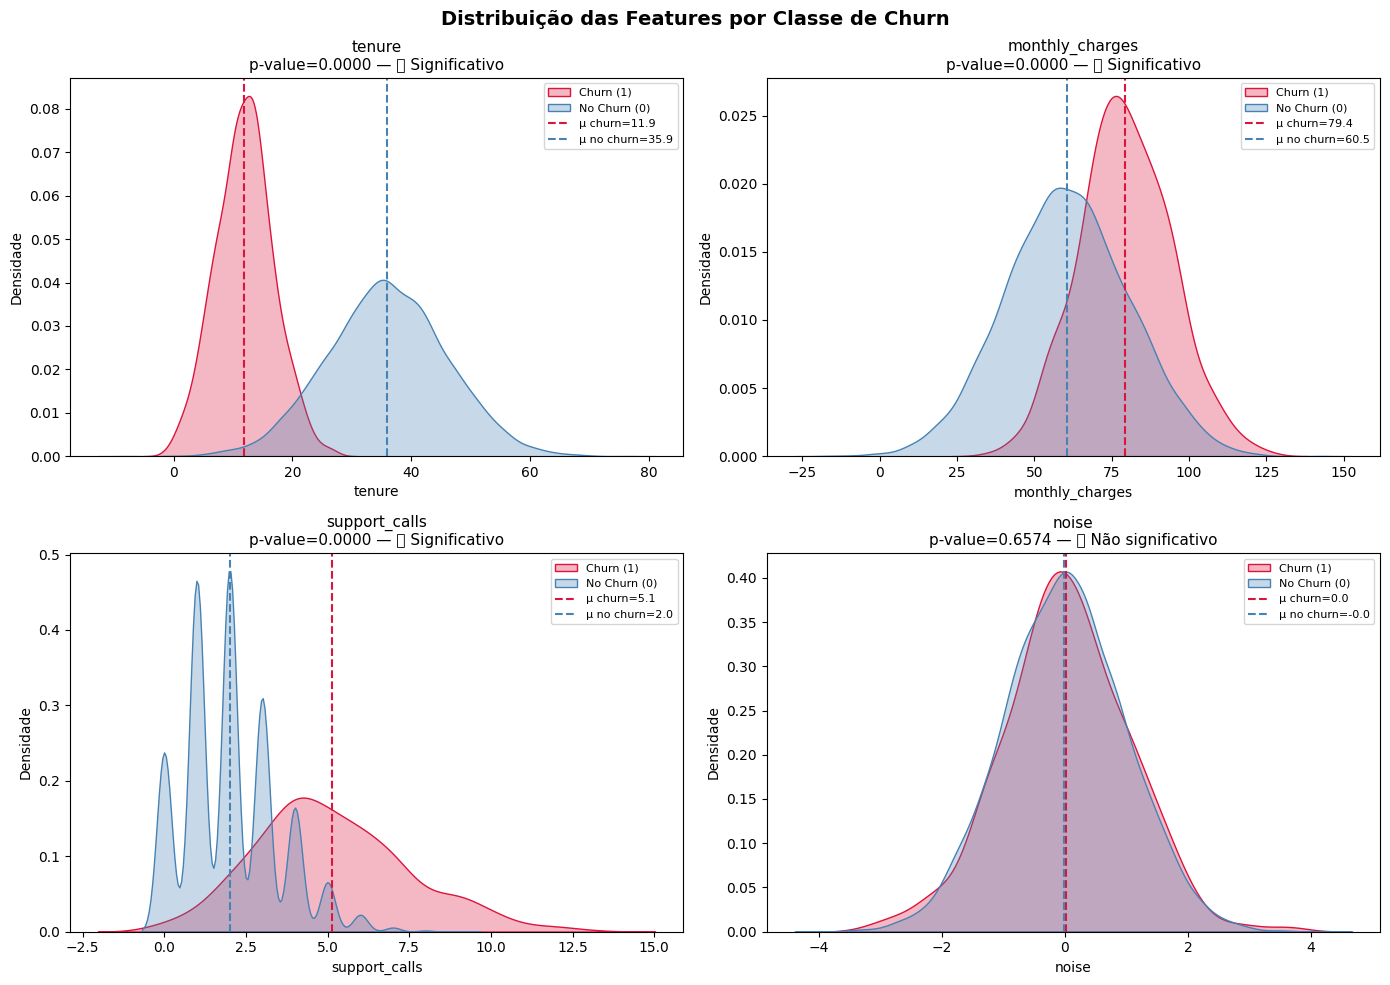


Feature                 μ Churn   μ No Churn    p-value  Importante?
--------------------------------------------------------------------
tenure                    11.93        35.90     0.0000        ✅ Sim
monthly_charges           79.43        60.47     0.0000        ✅ Sim
support_calls              5.12         2.01     0.0000        ✅ Sim
noise                      0.01        -0.01     0.6574        ❌ Não


In [18]:
rng = np.random.default_rng(seed=42)

# Simulando dataset de churn desbalanceado
n_total   = 10_000
n_churn   = 500    # 5%
n_no_churn = 9_500  # 95%

df = pd.DataFrame({
    'churn': [1]*n_churn + [0]*n_no_churn,

    # Feature 1 — tempo de uso (meses): churn usa MENOS
    'tenure': np.concatenate([
        rng.normal(loc=12, scale=5,  size=n_churn),
        rng.normal(loc=36, scale=10, size=n_no_churn)
    ]),

    # Feature 2 — valor mensal: churn paga MAIS (insatisfação)
    'monthly_charges': np.concatenate([
        rng.normal(loc=80, scale=15, size=n_churn),
        rng.normal(loc=60, scale=20, size=n_no_churn)
    ]),

    # Feature 3 — número de chamadas ao suporte
    'support_calls': np.concatenate([
        rng.poisson(lam=5, size=n_churn),
        rng.poisson(lam=2, size=n_no_churn)
    ]),

    # Feature 4 — ruído (não deve importar)
    'noise': rng.normal(loc=0, scale=1, size=n_total)
})

# --- Comparando distribuições entre grupos ---
features = ['tenure', 'monthly_charges', 'support_calls', 'noise']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), features):
    churn_vals    = df[df['churn'] == 1][feature]
    no_churn_vals = df[df['churn'] == 0][feature]

    # t-test
    t_stat, p_value = stats.ttest_ind(churn_vals, no_churn_vals)

    sns.kdeplot(churn_vals,    ax=ax, label='Churn (1)',    color='crimson',   fill=True, alpha=0.3)
    sns.kdeplot(no_churn_vals, ax=ax, label='No Churn (0)', color='steelblue', fill=True, alpha=0.3)

    ax.axvline(churn_vals.mean(),    color='crimson',   linestyle='--', linewidth=1.5,
               label=f'μ churn={churn_vals.mean():.1f}')
    ax.axvline(no_churn_vals.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'μ no churn={no_churn_vals.mean():.1f}')

    significance = "✅ Significativo" if p_value < 0.05 else "❌ Não significativo"
    ax.set_title(f'{feature}\np-value={p_value:.4f} — {significance}', fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Features por Classe de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Resumo numérico ---
print(f"\n{'Feature':<20} {'μ Churn':>10} {'μ No Churn':>12} {'p-value':>10} {'Importante?':>12}")
print("-" * 68)
for feature in features:
    churn_vals    = df[df['churn'] == 1][feature]
    no_churn_vals = df[df['churn'] == 0][feature]
    _, p_value    = stats.ttest_ind(churn_vals, no_churn_vals)
    importante    = "✅ Sim" if p_value < 0.05 else "❌ Não"
    print(f"{feature:<20} {churn_vals.mean():>10.2f} {no_churn_vals.mean():>12.2f} {p_value:>10.4f} {importante:>12}")

# EDA de Nível Sênior — Estatística Inferencial na Prática

## Resposta direta

> Sim — e essa é exatamente a diferença entre um analista
> que **descreve** os dados e um cientista de dados sênior
> que **toma decisões baseadas** nos dados.

---

## Os três níveis de EDA
```
Nível 1 — Descritivo (Júnior)
─────────────────────────────
"A média de tenure do grupo churn é 12 meses
 e do grupo no-churn é 36 meses"

Ferramentas: .describe(), .value_counts(), histogramas


Nível 2 — Visual (Pleno)
────────────────────────
"As distribuições parecem diferentes entre os grupos"

Ferramentas: KDE plots, boxplots, heatmaps


Nível 3 — Inferencial (Sênior) ← onde você quer chegar
───────────────────────────────
"A diferença de 24 meses entre os grupos é
 estatisticamente significativa (p < 0.05)
 e praticamente relevante (Cohen's d = 1.8)"

Ferramentas: t-test, z-test, chi-quadrado,
             effect size, intervalos de confiança
```

---

## O mapa completo — onde cada conceito entra na EDA

### Lei dos Grandes Números
```
Garante que sua média amostral converge para a média real
à medida que n cresce.

Na EDA:
├── Justifica usar a média como estimativa confiável
│   quando n é grande
└── Alerta para desconfiar de médias com n pequeno
    ex: "temos só 50 casos de churn — média instável"
```

### Central Limit Theorem
```
Garante que a sampling distribution é normal para n grande,
independente da distribuição original dos dados.

Na EDA:
├── Justifica usar t-test mesmo com dados não-normais
│   quando n é suficiente
├── Fundamenta intervalos de confiança para qualquer métrica
└── Permite comparar grupos mesmo com distribuições assimétricas
    ex: revenue (exponencial) → CLT normaliza a sampling dist.
```

### Hypothesis Testing
```
Transforma observações visuais em decisões quantificadas.

Na EDA:
├── t-test       → "essa feature contínua separa as classes?"
├── z-test       → "essa proporção é diferente entre grupos?"
├── chi-quadrado → "essa feature categórica é independente do target?"
├── ANOVA        → "existe diferença entre mais de 2 grupos?"
└── Correlação   → "essa relação é significativa ou é ruído?"
```

---

## Fluxo completo de EDA sênior no problema de churn
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(seed=42)

# Simulando dataset
n_churn    = 500
n_no_churn = 9_500

df = pd.DataFrame({
    'churn': [1]*n_churn + [0]*n_no_churn,
    'tenure': np.concatenate([
        rng.normal(12, 5,  n_churn),
        rng.normal(36, 10, n_no_churn)
    ]),
    'monthly_charges': np.concatenate([
        rng.normal(80, 15, n_churn),
        rng.normal(60, 20, n_no_churn)
    ]),
})

# ── Passo 1: Lei dos Grandes Números ──────────────────────────
# Verificar se n é suficiente para confiar nas médias
print("=== Passo 1 — Tamanho dos grupos ===")
print(df['churn'].value_counts())
print(f"\nn_churn={n_churn} → {'✅ suficiente' if n_churn >= 30 else '⚠️ pequeno'}")

# ── Passo 2: CLT — Verificar se podemos usar testes paramétricos ──
print("\n=== Passo 2 — Normalidade (CLT) ===")
for feature in ['tenure', 'monthly_charges']:
    for grupo, label in [(1, 'churn'), (0, 'no_churn')]:
        dados = df[df['churn'] == grupo][feature]
        _, p  = stats.shapiro(dados.sample(500))  # Shapiro-Wilk
        print(f"{feature} | {label}: p={p:.4f} "
              f"{'✅ normal' if p > 0.05 else '⚠️ não-normal — CLT justifica mesmo assim'}")

# ── Passo 3: Hypothesis Testing — features importantes? ──────────
print("\n=== Passo 3 — Teste de hipóteses por feature ===")
print(f"\n{'Feature':<20} {'μ churn':>8} {'μ no churn':>10} "
      f"{'p-value':>10} {'Cohen d':>8} {'Importa?':>10}")
print("-" * 72)

for feature in ['tenure', 'monthly_charges']:
    g1 = df[df['churn'] == 1][feature]
    g2 = df[df['churn'] == 0][feature]

    _, p_value = stats.ttest_ind(g1, g2)

    # Effect size — Cohen's d
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    cohens_d   = abs(g1.mean() - g2.mean()) / pooled_std

    importa = "✅ Sim" if p_value < 0.05 and cohens_d > 0.2 else "❌ Não"

    print(f"{feature:<20} {g1.mean():>8.1f} {g2.mean():>10.1f} "
          f"{p_value:>10.4f} {cohens_d:>8.2f} {importa:>10}")

# ── Passo 4: Intervalos de confiança para as médias ──────────────
print("\n=== Passo 4 — Intervalos de Confiança (95%) ===")
for feature in ['tenure', 'monthly_charges']:
    for grupo, label in [(1, 'churn'), (0, 'no_churn')]:
        dados = df[df['churn'] == grupo][feature]
        ic    = stats.t.interval(
            confidence=0.95,
            df=len(dados)-1,
            loc=dados.mean(),
            scale=stats.sem(dados)
        )
        print(f"{feature} | {label}: μ={dados.mean():.1f} "
              f"IC=[{ic[0]:.1f}, {ic[1]:.1f}]")
```

---

## O que cada passo usa

| Passo | Conceito | Pergunta respondida |
|---|---|---|
| 1 | Lei dos Grandes Números | "Posso confiar nas minhas médias?" |
| 2 | CLT | "Posso usar testes paramétricos?" |
| 3 | Hypothesis Testing | "Essa feature realmente separa as classes?" |
| 4 | Intervalo de Confiança | "Qual a incerteza da minha estimativa?" |

---

## A resposta que um sênior daria em entrevista

> *"Como você faz EDA em um problema de classificação desbalanceado?"*
```
1. Verifico o tamanho de cada classe — Lei dos Grandes Números
   me diz se posso confiar nas estatísticas descritivas

2. Para cada feature, comparo a distribuição entre as classes
   visualmente (KDE) e quantitativamente (t-test / chi-quadrado)

3. Uso effect size (Cohen's d) além do p-value — porque com
   n=10.000 até diferenças triviais ficam significativas

4. Reporto intervalos de confiança para as métricas principais
   em vez de apenas valores pontuais

5. Features com p < 0.05 E effect size relevante são candidatas
   — as demais provavelmente são ruído
```

> Isso é o que separa uma EDA descritiva de uma EDA que
> **justifica decisões de negócio com rigor estatístico**.

# Central Limit Theorem
___

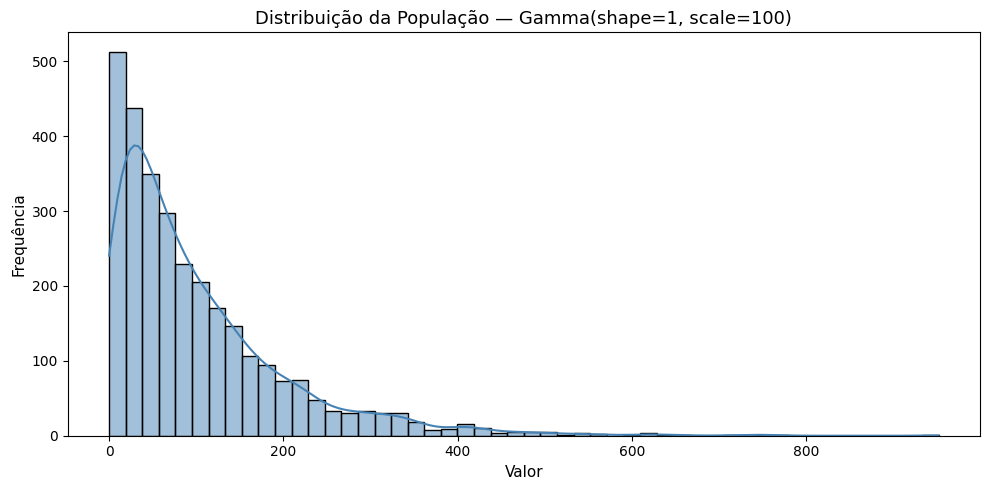

Média populacional  μ = 101.05
Desvio padrão       σ = 101.74
Variância           σ²= 10351.18


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seed moderna
rng = np.random.default_rng(seed=42)

# População — distribuição Gamma (assimétrica, não-normal)
pop_data = rng.gamma(shape=1, scale=100, size=3000)

# Plot com seaborn
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(pop_data, bins=50, kde=True, color='steelblue', ax=ax)

ax.set_title('Distribuição da População — Gamma(shape=1, scale=100)',
             fontsize=13)
ax.set_xlabel('Valor', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)

plt.tight_layout()
plt.show()

# Parâmetros reais da população
print(f"Média populacional  μ = {pop_data.mean():.2f}")
print(f"Desvio padrão       σ = {pop_data.std():.2f}")
print(f"Variância           σ²= {pop_data.var():.2f}")

`1.` In order to create the sampling distribution for the average of 3 draws of this distribution, follow these steps:

`a.` Use numpy's **random.choice** to simulate 3 draws from the `pop_data` array.   <br><br>
`b.` Compute the mean of these 3 draws. <br><br>
`c.` Write a loop to simulate this process 10,000 times, and store each mean into an array called **means_size_3**.<br><br>
`d.` Plot a histogram of your sample means.<br><br>
`e.` Use **means_size_3** and **pop_data** to answer the quiz questions below.

# CLT — Sampling Distribution com n=3

## a. Simulando 3 draws da população
```python
# Uma única amostra de tamanho 3
sample_3 = rng.choice(pop_data, size=3, replace=True)

print(f"3 draws:  {sample_3}")
print(f"Média:    {sample_3.mean():.2f}")
```

> **O que está acontecendo:**
> Retiramos 3 valores aleatórios da população Gamma.
> A média desses 3 valores é nossa primeira estimativa de μ.

---

## b. Média dos 3 draws
```python
mean_sample_3 = sample_3.mean()
print(f"Média da amostra: {mean_sample_3:.2f}")
print(f"Média real da população (μ): {pop_data.mean():.2f}")
print(f"Sampling error: {mean_sample_3 - pop_data.mean():.2f}")
```

> **O que está acontecendo:**
> Com apenas 3 draws, o sampling error tende a ser grande.
> A amostra é pequena — muita variabilidade.

---

## c. Loop de 10.000 simulações → means_size_3
```python
# Forma vetorizada — mais eficiente
samples_matrix = rng.choice(pop_data, size=(10_000, 3), replace=True)
means_size_3   = samples_matrix.mean(axis=1)

print(f"Shape da matrix:      {samples_matrix.shape}")
print(f"Shape de means_size_3: {means_size_3.shape}")
print(f"\nPrimeiras 5 médias: {means_size_3[:5].round(2)}")
```

> **O que está acontecendo:**
> Geramos uma matrix (10.000 × 3) de uma vez.
> Cada linha é uma amostra de tamanho 3.
> `axis=1` calcula a média de cada linha.
> Resultado: 10.000 médias amostrais.

---

## d. Histograma das médias amostrais
```python
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: População original ---
sns.histplot(pop_data, bins=50, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(pop_data.mean(), color='crimson',
                linestyle='--', linewidth=2,
                label=f'μ = {pop_data.mean():.2f}')
axes[0].set_title('População — Gamma(shape=1, scale=100)\n'
                  'Distribuição assimétrica', fontsize=12)
axes[0].set_xlabel('Valor', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].legend()

# --- Plot 2: Sampling distribution (n=3) ---
sns.histplot(means_size_3, bins=50, kde=True,
             color='darkorange', ax=axes[1])
axes[1].axvline(means_size_3.mean(), color='crimson',
                linestyle='--', linewidth=2,
                label=f'μ médias = {means_size_3.mean():.2f}')
axes[1].set_title('Sampling Distribution — n=3\n'
                  'Começando a simetrizar', fontsize=12)
axes[1].set_xlabel('Média Amostral', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].legend()

plt.suptitle('CLT em Ação — População Gamma vs Sampling Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
```

---

## e. Respondendo as questões com means_size_3 e pop_data
```python
print("=" * 52)
print("Comparação: População vs Sampling Distribution")
print("=" * 52)

print(f"\n{'Métrica':<30} {'População':>10} {'Means n=3':>10}")
print("-" * 52)
print(f"{'Média':<30} {pop_data.mean():>10.2f} "
      f"{means_size_3.mean():>10.2f}")
print(f"{'Variância':<30} {pop_data.var():>10.2f} "
      f"{means_size_3.var():>10.2f}")
print(f"{'Desvio Padrão':<30} {pop_data.std():>10.2f} "
      f"{means_size_3.std():>10.2f}")

# Variância teórica da sampling distribution
var_teorica = pop_data.var() / 3
se_teorico  = pop_data.std() / np.sqrt(3)
print(f"\n{'Variância teórica (σ²/n)':<30} {var_teorica:>10.2f}")
print(f"{'SE teórico (σ/√n)':<30} {se_teorico:>10.2f}")
print(f"{'SE simulado':<30} {means_size_3.std():>10.2f}")
```

---

## O que os resultados mostram
```
1. Média da sampling distribution ≈ μ da população
   → E[x̄] = μ  (estimador não-viesado) ✅

2. Variância da sampling distribution ≈ σ²/n
   → Var(x̄) = σ²/3  ✅

3. Com n=3 a distribuição ainda é assimétrica
   → CLT precisa de n maior para convergir
   → Com n=30+ a normal vai aparecer claramente
```

> O plot vai mostrar que a sampling distribution com n=3
> já é **mais simétrica** que a população Gamma original
> — mas ainda não é normal. Isso é esperado.
> O CLT converge gradualmente com o aumento de n.